Human Activity Recorgnition With 3-Axial Accelerometers
---
---
What are accelerometers?
An accelerometer is an electromechanical sensor that measures the physical aceleration, vibration or tilt of an object by tracking movement across spatial axes (X, Y and Z). It converts mechanical forces into measurable electrical signals to determine how speed or direction changes over time. They are used in smartphones, weawrables etc. (Todo: Rephrase this)
For a brief explanation on how accelerometers work (Including how readings are represented), see thie Youtube Video [here]()

In this project, we attempt to find patterns and recorgnize activies carried out by humans using data collected from accelerometers. 

#### Imports, Constants and Utility Functions
---

In [1]:
# ============================================================================
# Core Data Science & File Utilities -----------------------------------------
# ============================================================================
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks

# ============================================================================
# Data Visualization ---------------------------------------------------------
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# Scikit-Learn ---------------------------------------------------------------
# ============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# ============================================================================
# TensorFlow / Keras ---------------------------------------------------------
# ============================================================================
import tensorflow as tf

from tensorflow.keras.layers import (
    Conv1D,
    Dense,
    Dropout,
    Flatten,
    LSTM,
    MaxPooling1D,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

random_seed = 42

sns.set_theme(style="whitegrid")

current_dir = Path.cwd()
DATA_DIR = current_dir / 'data'
ORIGINAL_WISDM = DATA_DIR / 'WISDM_ar_v1.1_raw.csv'

def print_horizontal_line():
    print('-- -- -- -- ' * 50 )
    return

def run_pipeline(activity_df):
    return

---
#### The DataSet
---

In [2]:
activity_df = pd.read_csv(
    ORIGINAL_WISDM,
    header=None,
    names=["user_id", "activity", "timestamp", "x", "y", "z"],
    on_bad_lines="skip"
)

activity_df.head()

,user_id,activity,timestamp,x,y,z
0,33,Jogging,49105962326000,-0.694638,12.680544,0.503953
1,33,Jogging,49106062271000,5.012288,11.264028,0.953424
2,33,Jogging,49106112167000,4.903325,10.882658,-0.081722
3,33,Jogging,49106222305000,-0.612916,18.496431,3.023717
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164


---
#### Exploratory Dta Analysis
---
---


##### Distribution of activities in the dataset
---


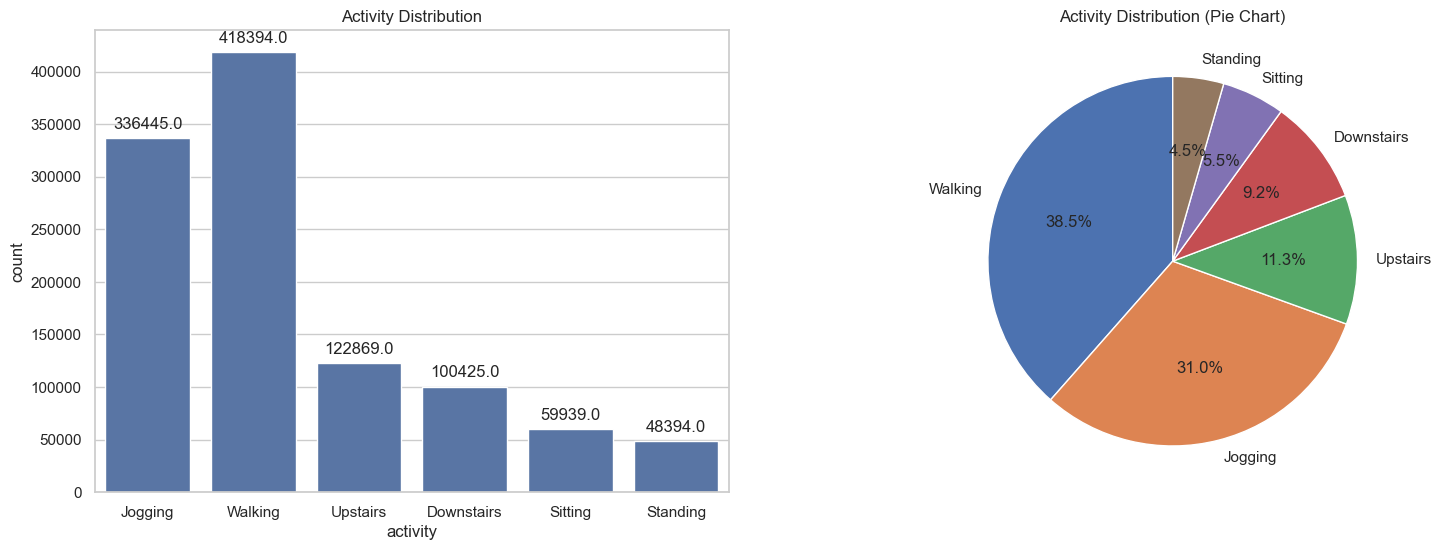

In [3]:
# Activity Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(data=activity_df, x='activity', ax=ax1)
ax1.set_title('Activity Distribution');

for p in ax1.patches:
    ax1.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')   

# pie plot of distribution of activities
activity_counts = activity_df['activity'].value_counts()
ax2.pie(activity_counts, labels=activity_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Activity Distribution (Pie Chart)');

From the plots, we see that the dataset is imbalanced, with jogging and walking accounnting for about 70% of the samples, and sitting and standing falling far behind. 
This means that there may be a tendency for our final model to be very good at predicting the jogging or walking classes, because it has more samples to learn from. 

In [4]:
print_horizontal_line()
print(f'{len(activity_df)} total samples')
print_horizontal_line()
activity_df.describe()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
1086466 total samples
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --

,user_id,timestamp,x,y,z
count,1.086466e+06,1.086466e+06,1.086466e+06,1.086466e+06,1.086465e+06
mean,1.883755e+01,3.250277e+13,6.641165e-01,7.246042e+00,3.976974e-01
std,1.026681e+01,4.893649e+13,6.876275e+00,6.739787e+00,4.761111e+00
min,1.000000e+00,0.000000e+00,-1.961000e+01,-1.961000e+01,-1.980000e+01
25%,1.000000e+01,1.999712e+12,-2.910000e+00,3.170000e+00,-2.220117e+00
50%,1.900000e+01,9.396193e+12,2.700000e-01,7.930000e+00,0.000000e+00
75%,2.800000e+01,3.509472e+13,4.440000e+00,1.156000e+01,2.720000e+00
max,3.600000e+01,2.093974e+14,1.995000e+01,2.004000e+01,1.961000e+01


In [5]:
print(activity_df.isna().sum())

user_id      0
activity     0
timestamp    0
x            0
y            0
z            1
dtype: int64


Remove Null Values (The one sample tht is incomplete)

In [6]:
activity_df[activity_df['z'].isna()]
activity_df.dropna(inplace=True)

Remove Duplicates

In [7]:
print_horizontal_line()
print(f'{len(activity_df)} Samples before dropping duplicates')
activity_df = activity_df.drop_duplicates()
print(f'{len(activity_df)} Samples after dropping duplicates')
print_horizontal_line()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
1086465 Samples before dropping duplicates
1019878 Samples after dropping duplicates
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --

#### Frequency Distribution of x, y, and z values
---

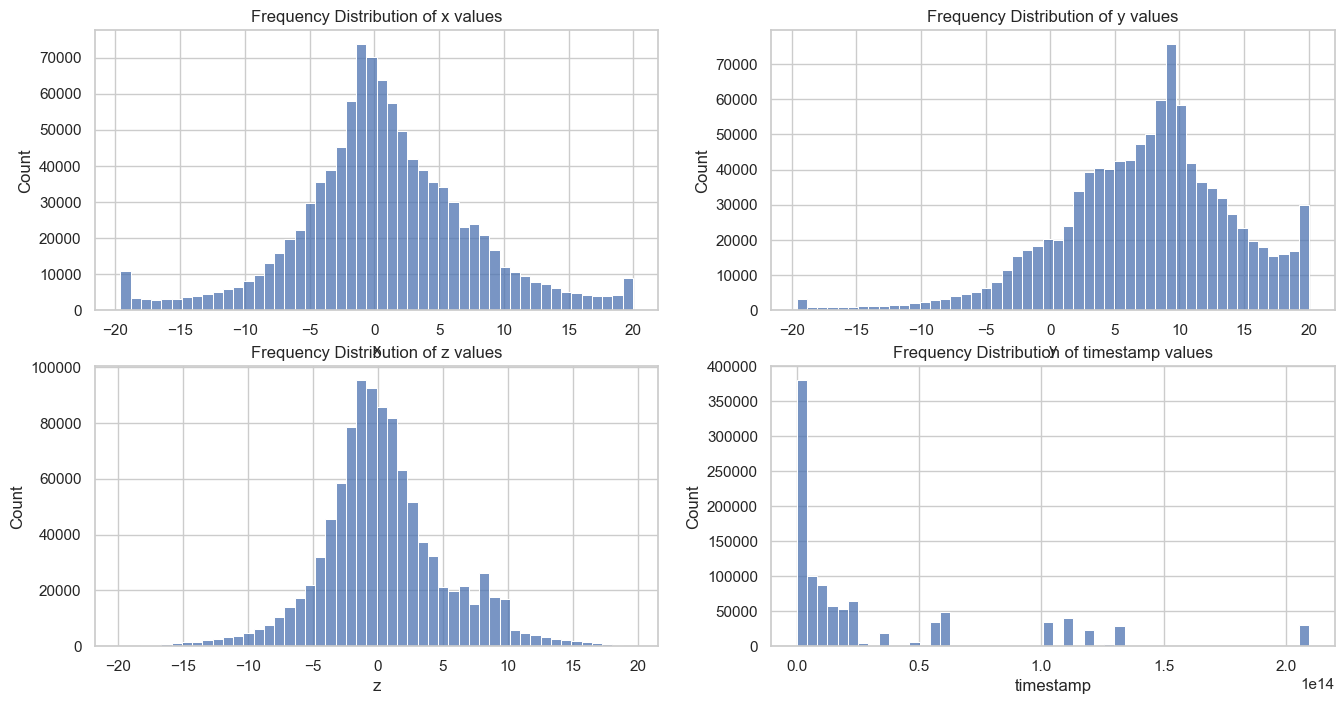

In [8]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 8));
sns.histplot(data=activity_df, x='x', bins=50, ax=ax1);
sns.histplot(data=activity_df, x='y', bins=50, ax=ax2);
sns.histplot(data=activity_df, x='z', bins=50, ax=ax3);
sns.histplot(data=activity_df, x='timestamp', bins=50, ax=ax4);
ax1.set_title('Frequency Distribution of x values');
ax2.set_title('Frequency Distribution of y values');
ax3.set_title('Frequency Distribution of z values');
ax4.set_title('Frequency Distribution of timestamp values');

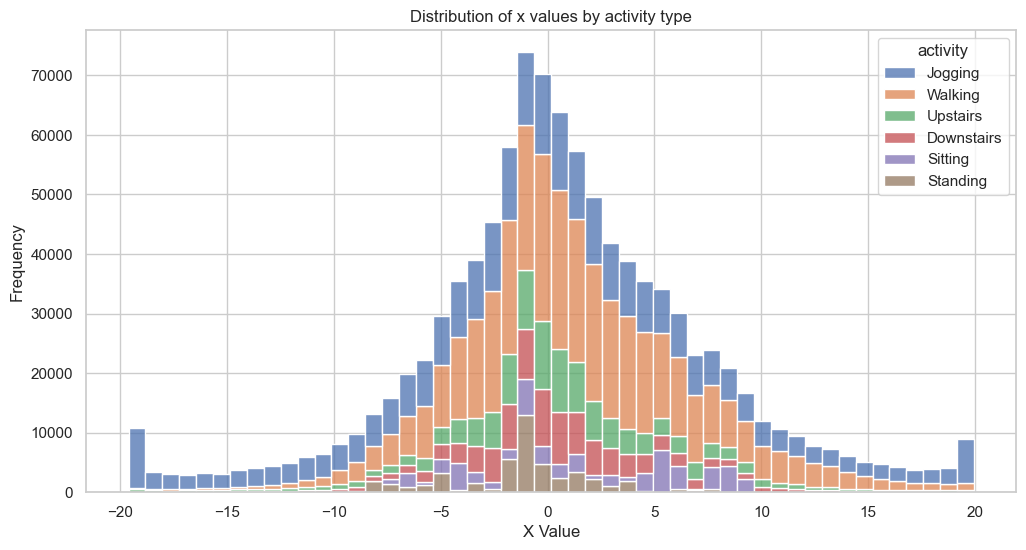

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 


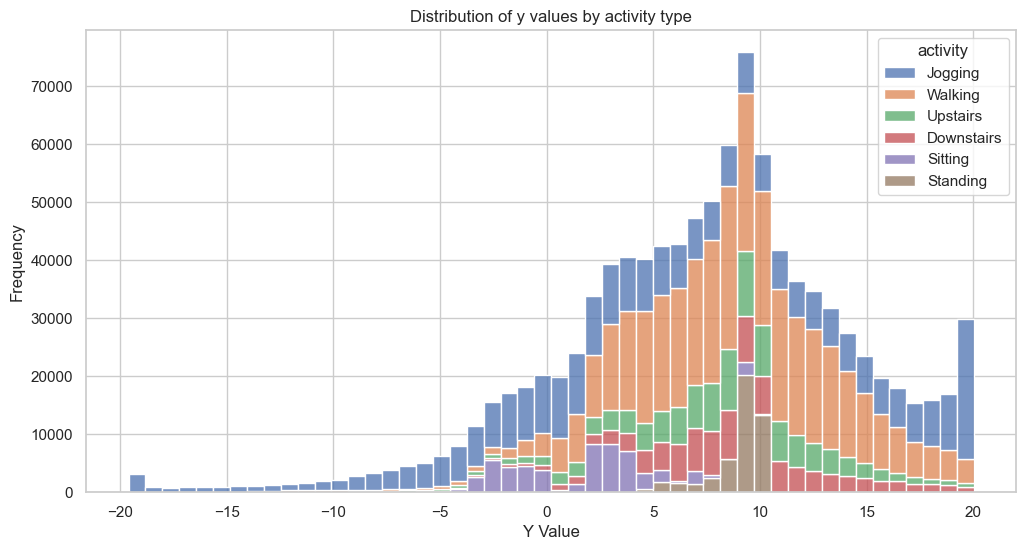

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 


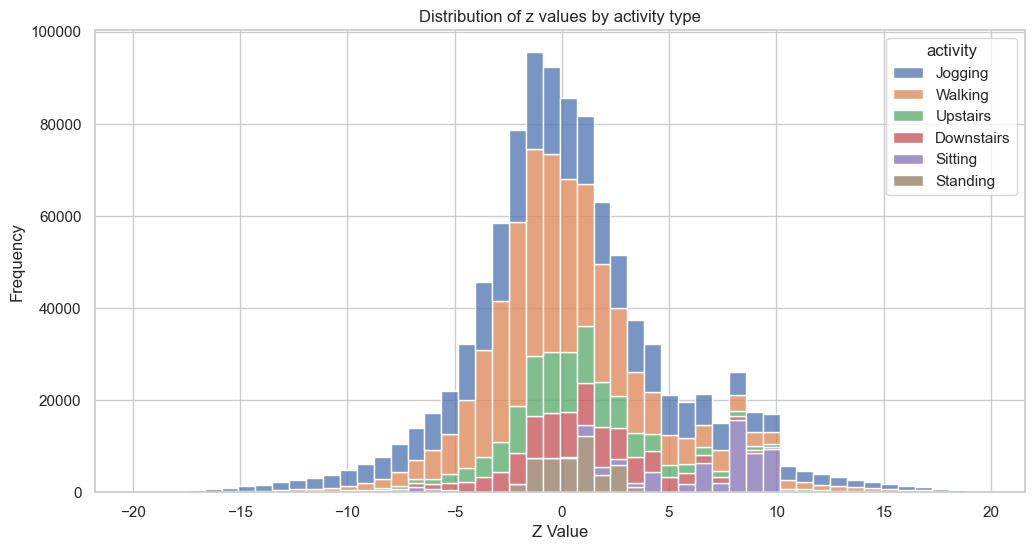

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 


In [9]:
# plot the distribution of x values for each activity type

def plot_activity_distributions(activity_df, title, xlabel, ylabel, column):
    plt.figure(figsize=(12, 6))
    sns.histplot(data=activity_df, x=column, hue='activity', bins=50, multiple='stack')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show();
    print_horizontal_line()

plot_activity_distributions(activity_df, 'Distribution of x values by activity type', 'X Value', 'Frequency', 'x')

plot_activity_distributions(activity_df, 'Distribution of y values by activity type', 'Y Value', 'Frequency', 'y')

plot_activity_distributions(activity_df, 'Distribution of z values by activity type', 'Z Value', 'Frequency', 'z')


The plots above show a heirarchy in activity types, with, standing showing the least readings, followed by sitting, stairs-decent, stairs-ascent, walking and jogging.
This supports the idea that the activity column should ordinal-encoded, with standing being the lowest value and jogging being the highest value.

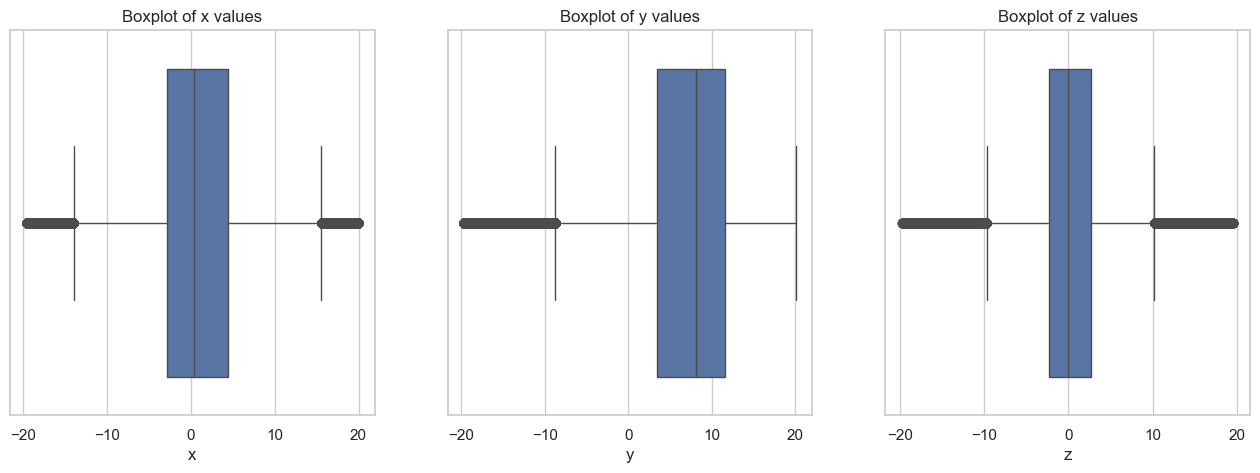

In [10]:
# plot boxplots for x, y and z values
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5));
sns.boxplot(data=activity_df, x='x', ax=ax1);
sns.boxplot(data=activity_df, x='y', ax=ax2);
sns.boxplot(data=activity_df, x='z', ax=ax3);

ax1.set_title('Boxplot of x values');
ax2.set_title('Boxplot of y values');
ax3.set_title('Boxplot of z values');

The boxplots indicate that there are a lot of outliers in the accelerometer data. However, we will not remove them as they may contain important information about types and speeds of movements. Instead, we will carry on, only scaling the data using a standard scaler. This will be done in our pre-processing step

In [11]:
print_horizontal_line()
print_horizontal_line()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 

Our dataset is comprised of thousands of snapshots of readings from accelerometers x, y and z, together with the timestamp at which that snapshot was recorded.
While these individual snapshots are important, they do not tell the full story of what activity is being perormed. This is because realisitically, activities are a set of fluid motions (or not) that are interlinked, performed over time. 

So, to see if someone is currently running, we need to see for the past x seconds, what movements the person was performing. The x-seconds, is called a window. And or the sake of consistency, we will keep the window size constant. 

The dataset was collected at roughly 20 samples/second (20Hz) (check the frequency distributions plotted or the x, y, and z columns above) [.]. We will use 5 seconds as our window, giving us a total of 100 samples or snapshots with which to classifify activities.  

Window 1:
[
 [x1,y1,z1],
 [x2,y2,z2],
 ...
 [x100,y100,z100]
] ==> Walking


Window 2:
[
 [x1,y1,z1],
 [x2,y2,z2],
 ...
 [x100,y100,z100]
] ==> Jogging

Window 3:
[
 [x1,y1,z1],
 [x2,y2,z2],
 ...
 [x100,y100,z100]
] ==> Walking

It is also important to introduce an overlap between the windows, so that the model does not miss out on interesting information stored in at the edges of the window. We will use an overlap that is 50% of the window samples. 
While this helps paint a better picture of the activity being performed, It also translates to longer training times and more memory consumption.

In [12]:
print_horizontal_line()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 


sort dataset by user_id and timestamps

In [13]:
activity_df.sort_values(by=['user_id', 'timestamp'], inplace=True)

#### User Distribution, Activity and Engagement
---

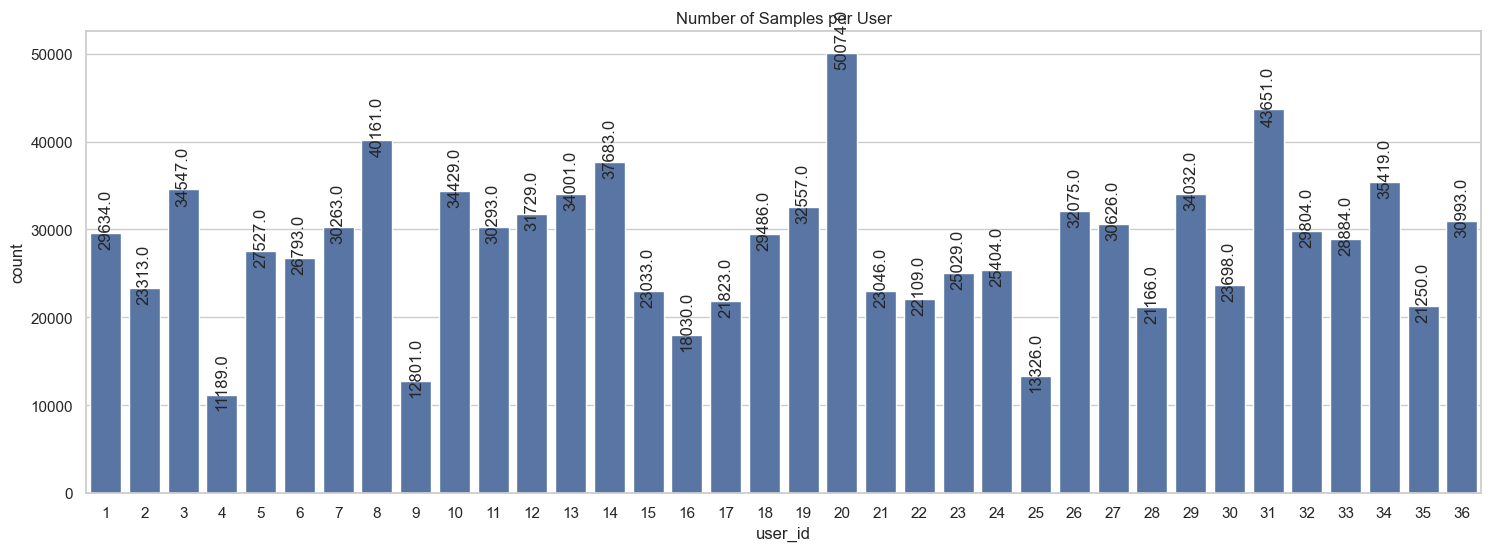

In [14]:
fig, ax1 = plt.subplots(1, 1, figsize=(18, 6))
# bar plot of distribution of number of samples per user
sns.countplot(data=activity_df, x='user_id', ax=ax1)
ax1.set_title('Number of Samples per User');
for p in ax1.patches:

    # set the annotation to be vertical
    ax1.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points', rotation=90) 

##### Did every user perform every activity?
---
User-level analysis is particularly important in human activity recognition because individuals exhibit unique movement patterns. To avoid data leakage and ensure generalizability, subject-independent evaluation methods such as leave-one-subject-out validation should be considered rather than random train-test splits.

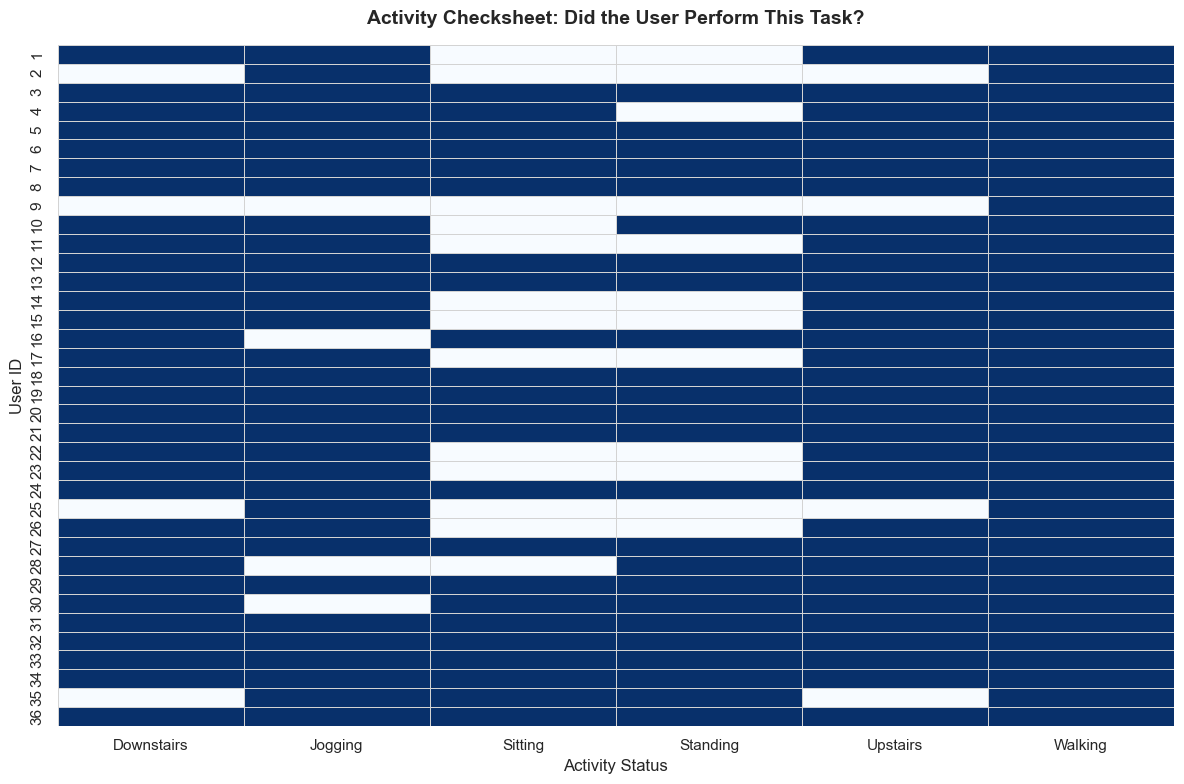

In [15]:
#check if each user performed all activities
check_list = pd.crosstab(
    activity_df["user_id"],
    activity_df["activity"]
)
# Convert sample counts into binary flags: 1 if they did it at all, 0 if completely missing
completion_matrix = (check_list > 0).astype(int)

plt.figure(figsize=(12, 8))
sns.heatmap(
    completion_matrix, 
    cmap="Blues", 
    cbar=False, 
    linewidths=0.5, 
    linecolor='lightgray'
)

plt.title("Activity Checksheet: Did the User Perform This Task?", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("User ID", fontsize=12)
plt.xlabel("Activity Status", fontsize=12)
plt.tight_layout()
plt.show()

---
The thing to note here is that, not all users performed all the activities. User 9, for example, only walked. User 2, only performed jogging and walking. 
Ultimately, Sitting and Standing are poorly represented. Overall, there is a risk that the model may learn person-specific patterns and not generalize properly.

As part of our model training, we will need to split the data into training and test sets. However, we won't be randomly splitting our data into these sets. 
We will split based on `user_id's`, using some samples `A-V` to train, `V-X` to test, and `Y-Z` to validate the performance of the model.

In [16]:
print_horizontal_line()
print_horizontal_line()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 

##### Comparison of accelerator values for different activities performed by one user (who completed all activities)
---

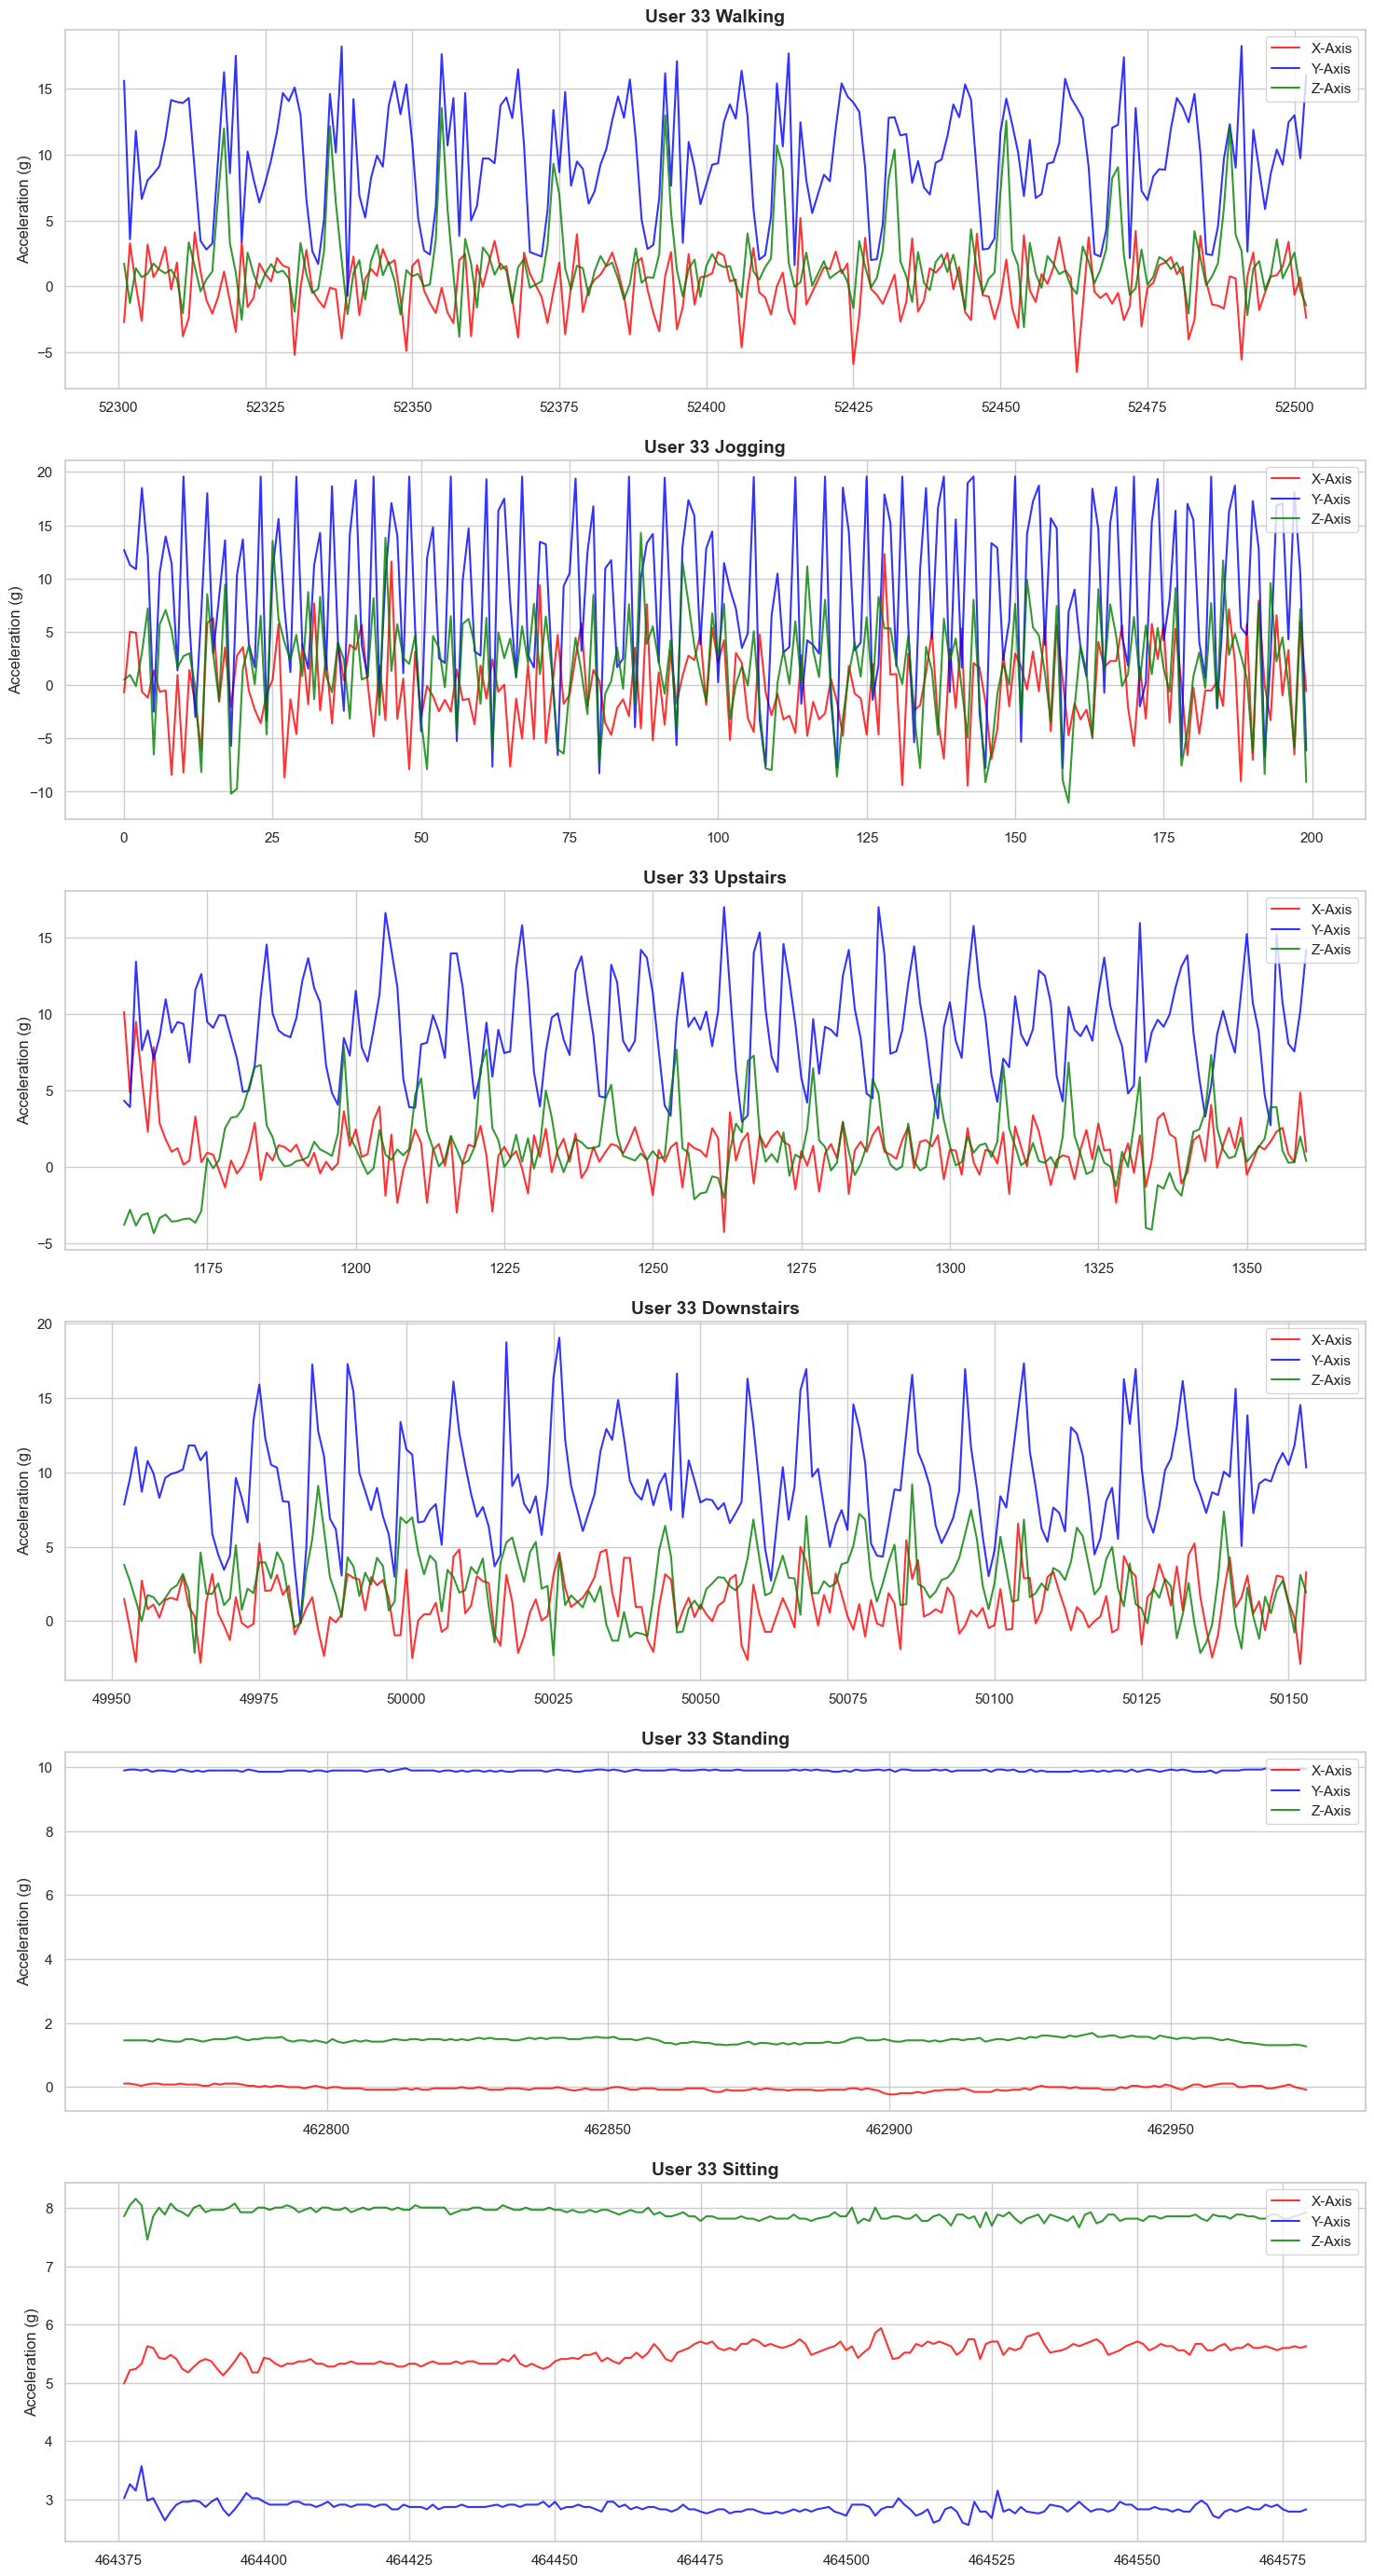

In [17]:
def get_user_activity_data(df, user_id, activity, num_samples=200):
    """Filters data for a specific user and activity, and returns a small sample."""
    sample = df[(df['user_id'] == user_id) & (df['activity'] == activity)].head(num_samples)
    return sample    

def plot_user_activity_sample(sample_df, title, ax):
    '''Plots the activity data for a specific user and activity.'''
    ax.plot(sample_df.index, sample_df['x'], label='X-Axis', color='red', alpha=0.8)
    ax.plot(sample_df.index, sample_df['y'], label='Y-Axis', color='blue', alpha=0.8)
    ax.plot(sample_df.index, sample_df['z'], label='Z-Axis', color='green', alpha=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Acceleration (g)', fontsize=12)
    ax.legend(loc='upper right')  

def get_user_33_data():

    user_33_jogging = get_user_activity_data(activity_df, user_id=33, activity='Jogging', num_samples=200) 
    user_33_standing = get_user_activity_data(activity_df, user_id=33, activity='Standing', num_samples=200)
    user_33_walking = get_user_activity_data(activity_df, user_id=33, activity='Walking', num_samples=200)
    user_33_sitting = get_user_activity_data(activity_df, user_id=33, activity='Sitting', num_samples=200)
    user_33_upstairs = get_user_activity_data(activity_df, user_id=33, activity='Upstairs', num_samples=200)
    user_33_downstairs = get_user_activity_data(activity_df, user_id=33, activity='Downstairs', num_samples=200)

    return (user_33_jogging, user_33_walking, user_33_downstairs, user_33_upstairs, user_33_sitting, user_33_standing)


user_33_jogging, user_33_walking, user_33_downstairs, user_33_upstairs, user_33_sitting, user_33_standing = get_user_33_data()

fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(nrows=6, ncols=1, figsize=(18, 35))

plot_user_activity_sample(user_33_walking, "User 33 Walking", ax1);
plot_user_activity_sample(user_33_jogging, "User 33 Jogging", ax2)
plot_user_activity_sample(user_33_upstairs, "User 33 Upstairs", ax3)
plot_user_activity_sample(user_33_downstairs, "User 33 Downstairs", ax4)
plot_user_activity_sample(user_33_standing, "User 33 Standing", ax5)
plot_user_activity_sample(user_33_sitting, "User 33 Sitting", ax6)

As shown in the plot above, the patterns recorded by the accelerometers differ with respect to activity. While walking, stairs-ascent and decent and jogging produce regular heavy spikes in the readings of the accelerometers, sitting and standing generally experience less violent spikes, and they happen far less frequently. 

somethings to note here are the frequency of the spikes and their amplitudes.
Also, there is a significant difference between the Y values for sitting and standing, with sitting recording lower values in general than standing. 

[todo: ask Prof how to explain this. In my opinion, it's because the gravitational pull has a stronger impact on the phone because it isn't resting on anything (as against when sitting...  to validate this, maybe compare the lowers points recorded for Y when jogging, walking etc.)]


---
#### Data Preprocessing
---

Human activity usually occurs at around 3.0Hz to 4.0Hz. Because of this, it is safe to assume that accelerometers that fall outside of this may be noise generated by the sensors and the effects of movements. 

To make sure that we are tracking only human activity, we need to filter out the noise. Below, we use a low pass filter, keeping our Nyquist frequency at 10Hz (half of our accelerometer sampling rates)

In [18]:
from scipy.signal import butter, filtfilt
print_horizontal_line()

print(f'{len(activity_df)} total samples before filtering')
       
print_horizontal_line()
# Define the filter properties
# The WISDM dataset is typically sampled at 20Hz. We set a cut-off at 4.0Hz 
# to capture human movement while filtering out high-frequency noise/vibrations.
def butter_lowpass_filter(data, cutoff=4.0, fs=20.0, order=4):
    nyq = 0.5 * fs  # Nyquist Frequency (absolute limit of the sensors, where readings can be captured without distortion)
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # filtfilt applies the filter forward and backward to ensure zero-phase shift
    return filtfilt(b, a, data)

# Apply to your existing dataframe columns
# Make sure to run this *after* your dropna() / drop_duplicates() steps
for axis in ['x', 'y', 'z']:
    activity_df[axis] = butter_lowpass_filter(activity_df[axis].values) # assign the filters

print(f'{len(activity_df)} total samples after filtering')
print_horizontal_line()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
1019878 total samples before filtering
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 

Plot User 33's data after denoising

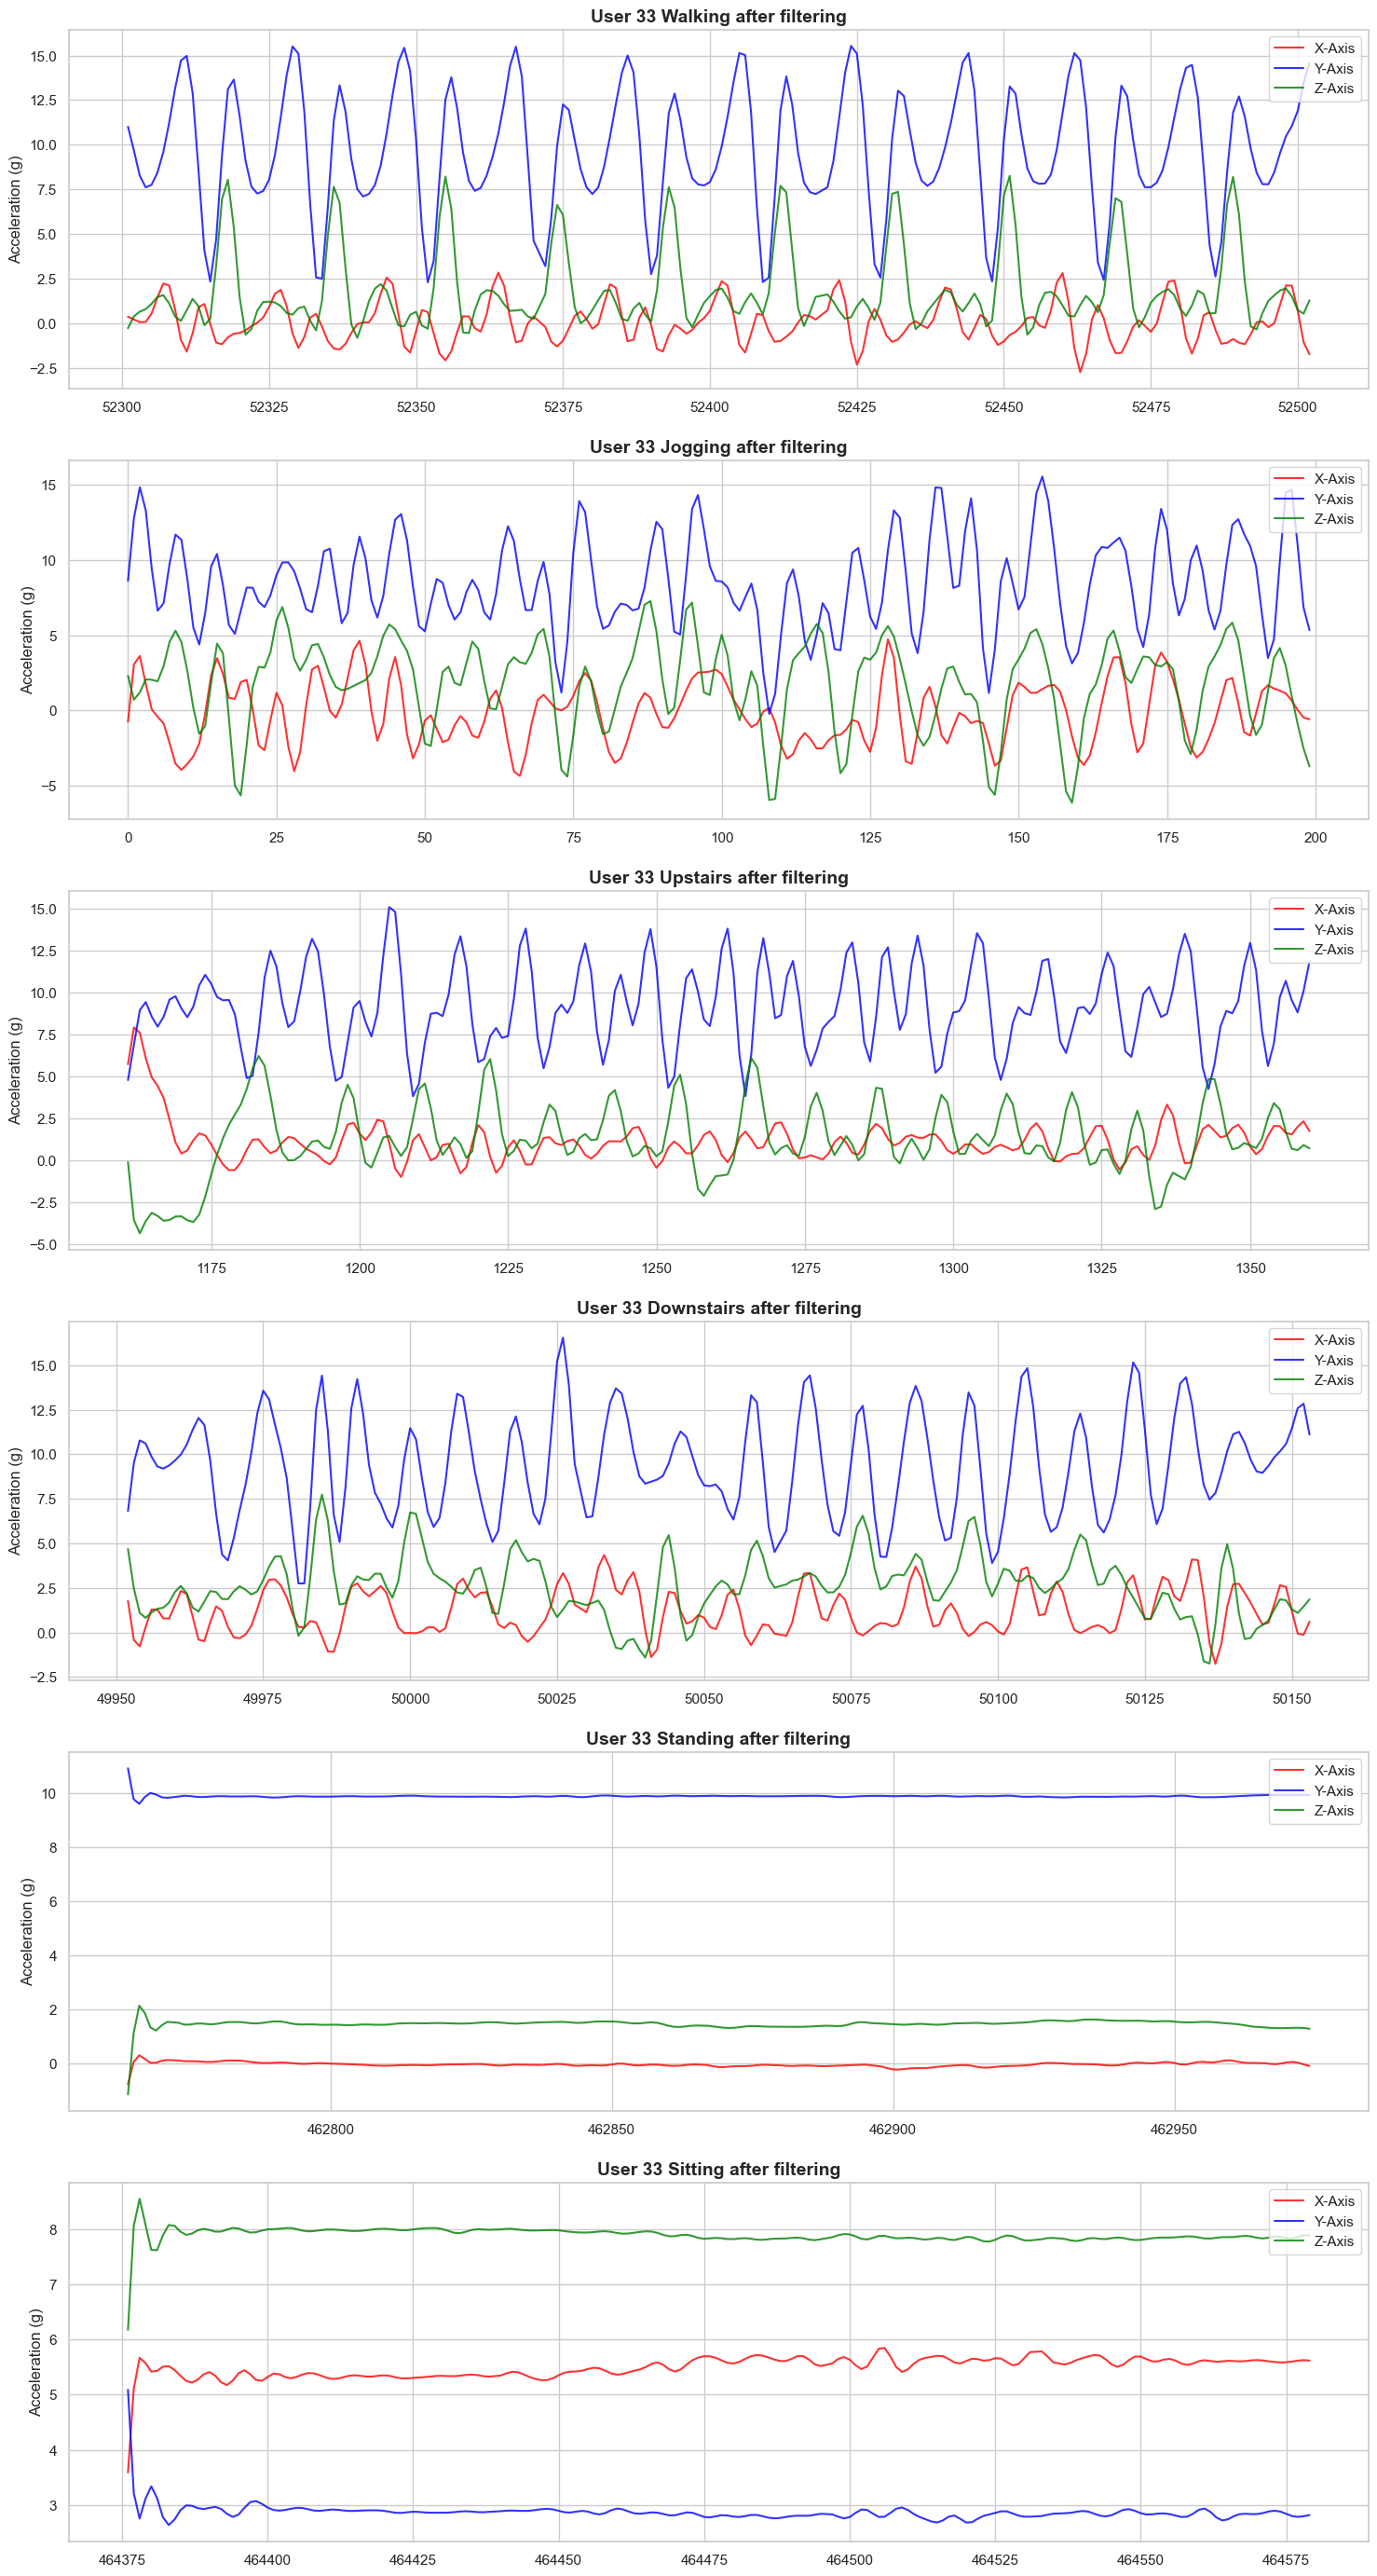

In [19]:
user_33_jogging, user_33_walking, user_33_downstairs, user_33_upstairs, user_33_sitting, user_33_standing = get_user_33_data()

fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(nrows=6, ncols=1, figsize=(18, 35))

plot_user_activity_sample(user_33_walking, "User 33 Walking after filtering", ax1);
plot_user_activity_sample(user_33_jogging, "User 33 Jogging after filtering", ax2)
plot_user_activity_sample(user_33_upstairs, "User 33 Upstairs after filtering", ax3)
plot_user_activity_sample(user_33_downstairs, "User 33 Downstairs after filtering", ax4)
plot_user_activity_sample(user_33_standing, "User 33 Standing after filtering", ax5)
plot_user_activity_sample(user_33_sitting, "User 33 Sitting after filtering", ax6)

##### Feature Engineering
___
While the x,y and z components are very important in activity classification, there are other pieces of information that are often needed. These bits of infomration need to be derived from the accelerometer values. 

1. Signal Magnitude Vector: The total acceleration experienced by phone, regardless of direction.
   [Magnitude = √(x² + y² + z²)]
2. Roll: How much the phone is rotated sideways [Roll = atan2(y, z) × (180/π)]
3. Pitch: Pitch measures forward and backward tilt. Pitch = atan2(
    -x,
    √(y² + z²)
)
4. Jerk: How quickly acceleration changes. Jerk_x = (x_t - x_(t-1)) / Δt
5. Magnitude of Jerk: Overall rate of change of acceleration
6. Mean acceleration: The average acceleration over a time window
   

In [20]:
frequency_sampling = 20  # Hz
dt = 1.0 / frequency_sampling  # time change (between recording samples) in seconds

# Magnitude (Signal Magnitude Vector)
activity_df["magnitude"] = np.sqrt(activity_df["x"]**2 + activity_df["y"]**2 + activity_df["z"]**2)

# Roll & Pitch (Spatial Orientation Angle Estimations)
activity_df["roll"] = np.degrees(np.arctan2(activity_df["y"], activity_df["z"]))
activity_df["pitch"] = np.degrees(np.arctan2(-activity_df["x"], np.sqrt(activity_df["y"]**2 + activity_df["z"]**2)))

# Jerk Vectors (First derivative of acceleration per user)
activity_df["jerk_x"] = activity_df.groupby("user_id")["x"].diff() / dt
activity_df["jerk_y"] = activity_df.groupby("user_id")["y"].diff() / dt
activity_df["jerk_z"] = activity_df.groupby("user_id")["z"].diff() / dt
activity_df["jerk_magnitude"] = np.sqrt(activity_df["jerk_x"]**2 + activity_df["jerk_y"]**2 + activity_df["jerk_z"]**2)

# Energy Metrics (Movement Intensity)
activity_df["energy_x"] = activity_df["x"]**2
activity_df["energy_y"] = activity_df["y"]**2
activity_df["energy_z"] = activity_df["z"]**2

# Window Mean Acceleration (5-second rolling average)
# get the rolling average for acceleration 
window_size = int(5 * frequency_sampling)  # 100 samples
activity_df["window_mean_acceleration"] = (
    activity_df.groupby("user_id")[["x", "y", "z"]]
    .rolling(window=window_size, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
    .mean(axis=1)
)

In [21]:
print_horizontal_line()
print(f'{len(activity_df)} Samples before dropping NA values')
activity_df.dropna(inplace=True)
activity_df.reset_index(drop=True, inplace=True)
print(f'{len(activity_df)} Samples after dropping NA values')
print_horizontal_line()

-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
1019878 Samples before dropping NA values
1019842 Samples after dropping NA values
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -

##### Distance covered and Time Taken
---

In [22]:
# check the sequence of activities covered... for example, is it sit --> stand --> walk --> upstairs --> jog --> downstairs etc

# notes: 
# The dataset does not contain transitional data (sit to stand, stand to walk, walk to jog etc)
# that means there will be no way to check how long it takes to complete a transition

# what we can do, is to try to calculate the distance covered by the the participants for each of the activities that they performed.

def calculate_cumulative_distance_covered(
    dataframe: pd.DataFrame, 
    sampling_rate_hz: int = 20
) -> pd.DataFrame:
    """
    Calculates the step-by-step cumulative distance covered by each participant
    for each of their physical activities using a peak-detection step-counting algorithm.
    """
    # Create a local copy to prevent modifying the original DataFrame in place
    df = dataframe.copy()

    # Calculate the raw 3D magnitude (removes dependency on phone orientation)
    acceleration_magnitude = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)

    # Subtract gravity/slow movement patterns using a rolling mean (detrending)
    rolling_gravity_baseline = acceleration_magnitude.rolling(
        window=sampling_rate_hz, 
        min_periods=1, 
        center=True
    ).mean()
    
    detrended_magnitude = acceleration_magnitude - rolling_gravity_baseline

    # Detect peaks that represent real physical steps
    # We require peaks to be at least half a second apart (sampling_rate_hz // 2)
    # and to have a vertical spike height (prominence) of at least 1.5.
    minimum_samples_between_steps = sampling_rate_hz // 2
    detected_step_indices, _ = find_peaks(
        detrended_magnitude, 
        distance=minimum_samples_between_steps, 
        prominence=1.5
    )

    # Map detected steps to a binary column
    df["is_step_detected"] = 0
    df.loc[detected_step_indices, "is_step_detected"] = 1

    # Assign realistic stride lengths based on the specific activity
    df["stride_length_meters"] = 0.0
    normalized_activities = df["activity"].astype(str).str.strip().str.lower()

    # Constants for average human stride lengths (in meters)
    AVERAGE_WALKING_STRIDE_METERS = 0.76
    AVERAGE_JOGGING_STRIDE_METERS = 1.14

    # Map walking (label "walking" or encoded integer "1")
    is_walking_action = (normalized_activities == "walking") | (normalized_activities == "1")
    df.loc[is_walking_action, "stride_length_meters"] = AVERAGE_WALKING_STRIDE_METERS

    # Map jogging (label "jogging" or encoded integer "2")
    is_jogging_action = (normalized_activities == "jogging") | (normalized_activities == "2")
    df.loc[is_jogging_action, "stride_length_meters"] = AVERAGE_JOGGING_STRIDE_METERS

    # Calculate cumulative distance grouped strictly by user AND activity
    # This ensures the distance resets back to 0.0 when a user starts a new activity block
    def compute_cumulative_meters_in_block(group):
        return (group["is_step_detected"] * group["stride_length_meters"]).cumsum()

    df["cumulative_distance_meters"] = (
        df.groupby(["user_id", "activity"])
        .apply(compute_cumulative_meters_in_block, include_groups=False)
        .reset_index(level=[0, 1], drop=True)
    )

    # Clean up temporary helper columns to keep the DataFrame tidy
    df.drop(columns=["is_step_detected", "stride_length_meters"], inplace=True)
    return df

activity_df = calculate_cumulative_distance_covered(activity_df, sampling_rate_hz=20)
activity_df.head()


,user_id,activity,timestamp,x,y,z,magnitude,roll,pitch,jerk_x,jerk_y,jerk_z,jerk_magnitude,energy_x,energy_y,energy_z,window_mean_acceleration,cumulative_distance_meters
0,1,Walking,4991972333000,1.496582,7.439845,-1.768593,7.792238,103.372096,-11.073061,16.081713,-67.231584,5.210243,69.324267,2.239757,55.351297,3.127920,2.772108,0.0
1,1,Walking,4992022351000,0.163919,5.187975,-1.387491,5.372810,104.972970,-1.748310,-26.653250,-45.037401,7.622035,52.885334,0.026870,26.915087,1.925131,2.288562,0.0
2,1,Walking,4992072339000,-0.739138,4.855423,-0.115394,4.912715,91.361434,8.653245,-18.061150,-6.651052,25.441940,31.901943,0.546325,23.575129,0.013316,2.049829,0.0
3,1,Walking,4992122358000,2.549291,6.415700,2.187788,7.241997,71.170347,-20.610608,65.768588,31.205556,46.063645,86.146115,6.498885,41.161212,4.786418,2.383382,0.0
4,1,Walking,4992172376000,8.354470,8.854118,3.854034,12.768953,66.477399,-40.865075,116.103575,48.768354,33.324908,130.264891,69.797166,78.395407,14.853577,3.156297,0.0


##### Time Taken to Complete each activity
This will be calculated as  ($\Delta t = t_{\text{end}} - t_{\text{start}}$) where t is the time. 

In [23]:
def calculate_activity_durations(
    dataframe: pd.DataFrame, 
    sampling_rate_hz: int = 20
) -> pd.DataFrame:
    """
    Calculates the cumulative duration (in seconds) of continuous activity bouts
    for each participant, expanding them into distinct columns:
    sit_duration, stand_duration, Walk_duration, upstairs_duration, downstairs_duration.
    """
    df = dataframe.copy()
    
    # Identify contiguous activity blocks per user
    # The block ID increments only when the activity changes or when we switch to a new user
    is_new_activity = df["activity"] != df["activity"].shift()
    is_new_user = df["user_id"] != df["user_id"].shift()
    df["block_id"] = (is_new_activity | is_new_user).cumsum()
    
    # Calculate duration of each contiguous block using the sampling rate
    # Duration (seconds) = Total samples in the block / Sampling Frequency (Hz)
    block_durations = (
        df.groupby(["block_id", "activity"])
        .size()
        .reset_index(name="duration_seconds")
    )
    block_durations["duration_seconds"] = block_durations["duration_seconds"] / sampling_rate_hz
    
    # Pivot the long-format durations into separate activity-specific columns
    duration_pivot = block_durations.pivot(
        index="block_id", 
        columns="activity", 
        values="duration_seconds"
    ).fillna(0.0)
    
    column_mapping = {
        "sitting": "sit_duration",
        "standing": "stand_duration",
        "walking": "Walk_duration",
        "upstairs": "upstairs_duration",
        "downstairs": "downstairs_duration"
    }
    duration_pivot = duration_pivot.rename(columns=column_mapping)
    
    # Ensure all 5 target columns are present in the final output, even if omitted in this slice
    target_cols = [
        "sit_duration", 
        "stand_duration", 
        "Walk_duration", 
        "upstairs_duration", 
        "downstairs_duration"
    ]
    duration_pivot = duration_pivot.reindex(columns=target_cols, fill_value=0.0)
    
    # Merge the calculated wide durations back to the main dataframe
    df_final = df.merge(duration_pivot, left_on="block_id", right_index=True)
    
    # Clean up the helper block_id column
    df_final.drop(columns=["block_id"], inplace=True)
    return df_final

# Execute the duration calculation directly on your pipeline DataFrame
activity_df = calculate_activity_durations(activity_df, sampling_rate_hz=20)
print(len(activity_df))
activity_df.head()

1019842


,user_id,activity,timestamp,x,y,z,magnitude,roll,pitch,jerk_x,...,energy_x,energy_y,energy_z,window_mean_acceleration,cumulative_distance_meters,sit_duration,stand_duration,Walk_duration,upstairs_duration,downstairs_duration
0,1,Walking,4991972333000,1.496582,7.439845,-1.768593,7.792238,103.372096,-11.073061,16.081713,...,2.239757,55.351297,3.127920,2.772108,0.0,0.0,0.0,0.0,0.0,0.0
1,1,Walking,4992022351000,0.163919,5.187975,-1.387491,5.372810,104.972970,-1.748310,-26.653250,...,0.026870,26.915087,1.925131,2.288562,0.0,0.0,0.0,0.0,0.0,0.0
2,1,Walking,4992072339000,-0.739138,4.855423,-0.115394,4.912715,91.361434,8.653245,-18.061150,...,0.546325,23.575129,0.013316,2.049829,0.0,0.0,0.0,0.0,0.0,0.0
3,1,Walking,4992122358000,2.549291,6.415700,2.187788,7.241997,71.170347,-20.610608,65.768588,...,6.498885,41.161212,4.786418,2.383382,0.0,0.0,0.0,0.0,0.0,0.0
4,1,Walking,4992172376000,8.354470,8.854118,3.854034,12.768953,66.477399,-40.865075,116.103575,...,69.797166,78.395407,14.853577,3.156297,0.0,0.0,0.0,0.0,0.0,0.0


#### Further Exploratory Data Analysis
---

In [24]:
# 1. Sit-to-Stand Duration Analysis
# Filter data for sitting and standing to find transition gaps
sit_stand_df = activity_df[activity_df['activity'].isin(['Sitting', 'Standing'])].copy()
sit_stand_df = sit_stand_df.sort_values(by=['user_id', 'timestamp'])

# Convert timestamp from nanoseconds to seconds
sit_stand_df['timestamp_sec'] = sit_stand_df['timestamp'] / 1e12

# Find sequence transitions per user
sit_stand_df['prev_activity'] = sit_stand_df.groupby('user_id')['activity'].shift(1)
sit_stand_df['prev_timestamp'] = sit_stand_df.groupby('user_id')['timestamp_sec'].shift(1)

# A transition occurs when the activity changes from Sitting to Standing
transitions = sit_stand_df[
    (sit_stand_df['prev_activity'] == 'Sitting') & 
    (sit_stand_df['activity'] == 'Standing')
].copy()

# Calculate duration (filtering out anomalies/long gaps > 10 seconds)
transitions['duration'] = transitions['timestamp_sec'] - transitions['prev_timestamp']
valid_transitions = transitions[(transitions['duration'] > 0) & (transitions['duration'] <= 10)]

sit_stand_df.head()

# 2. Distance Proxy Analysis (Walking vs Jogging)
# Calculate acceleration magnitude: |a| = sqrt(x^2 + y^2 + z^2)
walk_jog_df = activity_df[activity_df['activity'].isin(['Walking', 'Jogging'])].copy()
walk_jog_df['accel_mag'] = np.sqrt(walk_jog_df['x']**2 + walk_jog_df['y']**2 + walk_jog_df['z']**2)

# Group by user and activity to find cumulative structural motion (proxy for distance)
distance_proxy = walk_jog_df.groupby(['user_id', 'activity'])['accel_mag'].sum().reset_index()
distance_proxy.rename(columns={'accel_mag': 'distance_proxy'}, inplace=True)


/var/folders/kd/_95qw9m91qs3wnjsnqrxp55r0000gn/T/ipykernel_69016/3247040985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


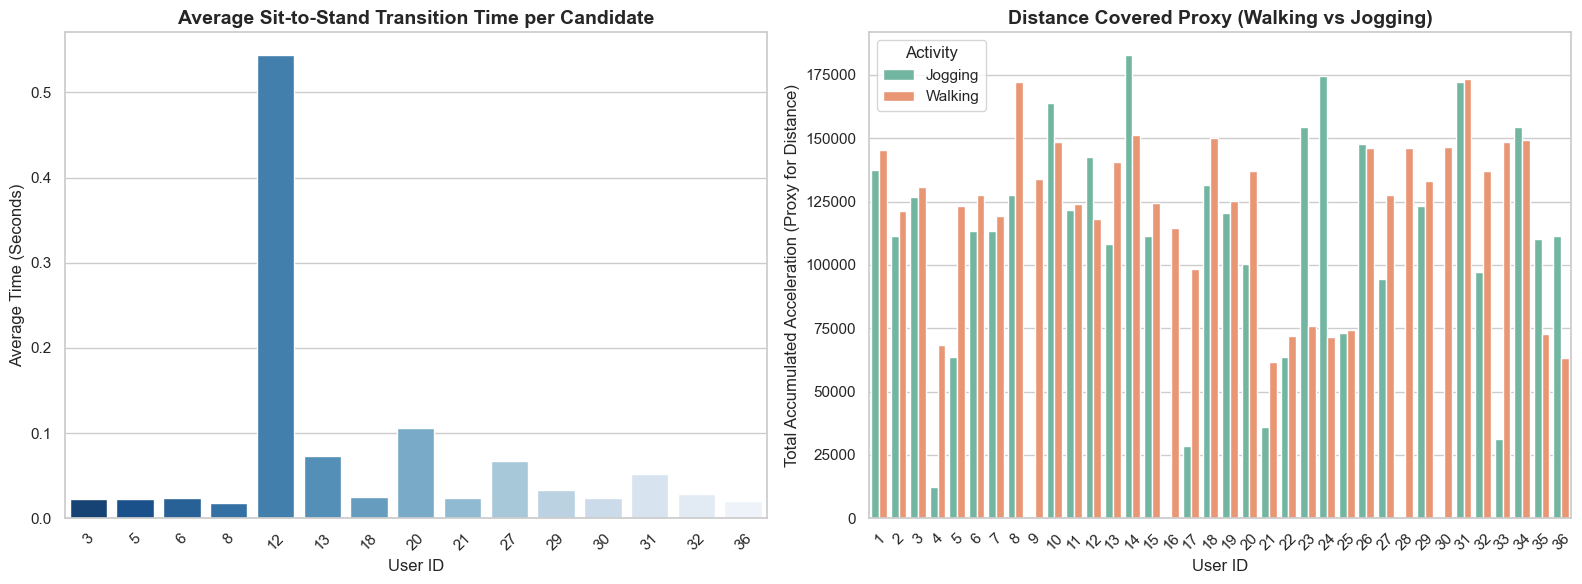

In [25]:
# plots

# Plotting Generation --------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Sit-to-Stand Average Time
sns.barplot(
    ax=axes[0],
    data=valid_transitions,
    x='user_id',
    y='duration',
    errorbar=None,
    palette='Blues_r'
)
axes[0].set_title('Average Sit-to-Stand Transition Time per Candidate', fontsize=14, fontweight='bold')
axes[0].set_xlabel('User ID', fontsize=12)
axes[0].set_ylabel('Average Time (Seconds)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot B: Distance Covered Proxy (Walking vs Jogging)
sns.barplot(
    ax=axes[1],
    data=distance_proxy,
    x='user_id',
    y='distance_proxy',
    hue='activity',
    palette='Set2'
)
axes[1].set_title('Distance Covered Proxy (Walking vs Jogging)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('User ID', fontsize=12)
axes[1].set_ylabel('Total Accumulated Acceleration (Proxy for Distance)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Activity')

plt.tight_layout()
plt.show()

Population-level analysis of sit-to-stand times, and distances covered while walking and joging

=== POPULATION AVERAGE METRICS ===
Average Sit-to-Stand Duration : 0.07 seconds
Average Walking Distance Proxy : 121,504.25 units
Average Jogging Distance Proxy : 111,314.35 units



/var/folders/kd/_95qw9m91qs3wnjsnqrxp55r0000gn/T/ipykernel_69016/1531231542.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/kd/_95qw9m91qs3wnjsnqrxp55r0000gn/T/ipykernel_69016/1531231542.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


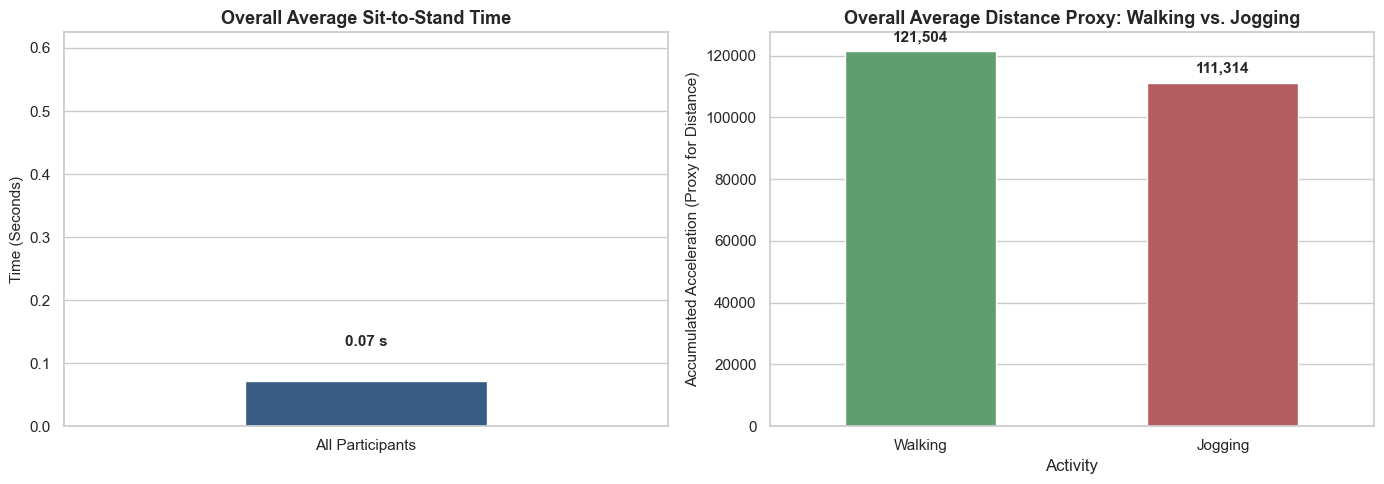

In [26]:
# Population-Level Summary Calculations --------------------------------------

# 1. Average Sit-to-Stand Time across all participants
avg_sit_stand_time = valid_transitions['duration'].mean()

# 2 & 3. Average Distance Proxy for Walking and Jogging across all participants
avg_distances = distance_proxy.groupby('activity')['distance_proxy'].mean()
avg_walk_dist = avg_distances.get('Walking', 0)
avg_jog_dist = avg_distances.get('Jogging', 0)

# Display numerical summary
print("=== POPULATION AVERAGE METRICS ===")
print(f"Average Sit-to-Stand Duration : {avg_sit_stand_time:.2f} seconds")
print(f"Average Walking Distance Proxy : {avg_walk_dist:,.2f} units")
print(f"Average Jogging Distance Proxy : {avg_jog_dist:,.2f} units\n")

# Visualization --------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average Sit-to-Stand Duration
sns.barplot(
    ax=axes[0],
    x=['All Participants'],
    y=[avg_sit_stand_time],
    palette=['#2b5c8f'],
    width=0.4
)
axes[0].set_title('Overall Average Sit-to-Stand Time', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Time (Seconds)', fontsize=11)
axes[0].set_ylim(0, max(valid_transitions['duration'].max(), avg_sit_stand_time) * 1.15)

# Annotate value on top of bar
axes[0].text(
    0, avg_sit_stand_time + 0.05, 
    f'{avg_sit_stand_time:.2f} s', 
    ha='center', va='bottom', fontsize=11, fontweight='bold'
)

# Plot 2: Average Distance Covered (Walking vs Jogging)
dist_summary_df = pd.DataFrame({
    'Activity': ['Walking', 'Jogging'],
    'Avg_Distance_Proxy': [avg_walk_dist, avg_jog_dist]
})

sns.barplot(
    ax=axes[1],
    data=dist_summary_df,
    x='Activity',
    y='Avg_Distance_Proxy',
    palette=['#55a868', '#c44e52'],
    width=0.5
)
axes[1].set_title('Overall Average Distance Proxy: Walking vs. Jogging', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accumulated Acceleration (Proxy for Distance)', fontsize=11)

# Annotate values on top of bars
for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom', fontsize=11, fontweight='bold',
        xytext=(0, 5), textcoords='offset points'
    )

plt.tight_layout()
plt.show();

##### Time Series Segmentation
---

In [27]:
def create_segments_and_labels(df, window_size=128, hop_size=64):
    """
    Slices the continuous dataframe into overlapping windows.
    Ensures data doesn't bleed across different users or different activities.
    """
    segments = []
    labels = []
    
    # Group by user and activity so we don't mix one person's walk with another's run
    grouped = df.groupby(['user_id', 'activity'])
    
    for names, group in grouped:
        # Extract the underlying numpy array for speed (X, Y, Z columns)
        feature_array = group[['x', 'y', 'z']].values
        # The activity label for this group
        label = names[1] 
        print(f"label ---> {label}")
        print(f"Processing user {names[0]} with activity {label} and {len(feature_array)} samples.")
        
        # Slide the window over the current group's time series
        for start_idx in range(0, len(feature_array) - window_size + 1, hop_size):
            window = feature_array[start_idx : start_idx + window_size]
            segments.append(window)
            labels.append(label)
            
    return np.array(segments), np.array(labels)

#Apply the function
X, y = create_segments_and_labels(activity_df, window_size=128, hop_size=64)

#Check the output dimensions
print(f"Features shape (Tensor): {X.shape}")
print(f"Labels shape: {y.shape}")

label ---> Downstairs
Processing user 1 with activity Downstairs and 2909 samples.
label ---> Jogging
Processing user 1 with activity Jogging and 10871 samples.
label ---> Upstairs
Processing user 1 with activity Upstairs and 3095 samples.
label ---> Walking
Processing user 1 with activity Walking and 12758 samples.
label ---> Jogging
Processing user 2 with activity Jogging and 11664 samples.
label ---> Walking
Processing user 2 with activity Walking and 11648 samples.
label ---> Downstairs
Processing user 3 with activity Downstairs and 3261 samples.
label ---> Jogging
Processing user 3 with activity Jogging and 10857 samples.
label ---> Sitting
Processing user 3 with activity Sitting and 1547 samples.
label ---> Standing
Processing user 3 with activity Standing and 2721 samples.
label ---> Upstairs
Processing user 3 with activity Upstairs and 3359 samples.
label ---> Walking
Processing user 3 with activity Walking and 12801 samples.
label ---> Downstairs
Processing user 4 with activit

##### Regression Segments and Models 
---

In [28]:
def create_regression_segments_and_features(df, window_size=60):
    """
    Finds transition events and extracts a temporal window (block) around them.
    Computes aggregated statistical features over each block to predict the transition duration.
    """
    # Locate the indices of the transition events
    transition_indices = df[df["sit_stand_time"] > 0].index
    
    features_list = []
    targets_list = []
    
    # Define features we want to calculate over the block
    # We prioritize base signals to compute robust summary statistics
    base_signals = ["x", "y", "z", "magnitude", "roll", "pitch"]
    available_signals = [col for col in base_signals if col in df.columns]
    
    half_window = window_size // 2
    
    for idx in transition_indices:
        # Define block boundary centered around the transition index
        start_idx = max(0, idx - half_window)
        end_idx = min(len(df) - 1, idx + half_window)
        
        # Extract the time block
        block = df.loc[start_idx:end_idx]
        
        # Calculate summary features representing the dynamics of this block
        block_features = {}
        for col in available_signals:
            block_features[f"{col}_mean"] = block[col].mean()
            block_features[f"{col}_std"] = block[col].std()
            block_features[f"{col}_min"] = block[col].min()
            block_features[f"{col}_max"] = block[col].max()
            block_features[f"{col}_range"] = block[col].max() - block[col].min()
            
        # Additional features calculated if present
        for jerk_col in ["jerk_x", "jerk_y", "jerk_z", "jerk_magnitude"]:
            if jerk_col in block.columns:
                block_features[f"{jerk_col}_mean"] = block[jerk_col].mean()
                block_features[f"{jerk_col}_max"] = block[jerk_col].max()
                
        for energy_col in ["energy_x", "energy_y", "energy_z"]:
            if energy_col in block.columns:
                block_features[f"{energy_col}_mean"] = block[energy_col].mean()

        features_list.append(block_features)
        targets_list.append(df.loc[idx, "sit_stand_time"])
        
    return pd.DataFrame(features_list), np.array(targets_list)


##### Time Taken to Switch Activities

Because our dataset lacks explicit "transition" labels (the data instantly switches from "Sitting" to "Standing"), calculating transition times requires a bit of clever engineering.If we rely purely on the label boundary, the transition time would always be exactly 1 sample interval (e.g., $1 / 20\text{ Hz} = 0.05\text{ seconds}$), which is physically meaningless.To solve this, we can use a sensor-driven heuristic approach. When a person transitions (e.g., sits to stands, or sits to walks), their acceleration goes from perfectly static (low variance) to a dynamic spike (high variance), and then back to a stable state.By analyzing a small window of sensor data around the exact moment the label switches, we can calculate the physical transition duration based on when the body was actually in motion.

In [29]:
def calculate_transition_durations(
    sensor_dataframe: pd.DataFrame, 
    sampling_rate_hz: int = 20,
    window_seconds: int = 3
) -> pd.DataFrame:
    """
    Detects transitions between specific activities (sit-stand, walk-jog, sit-walk)
    and calculates the physical duration of the movement using acceleration variance.
    """
    df = sensor_dataframe.copy()
    
    # Ensure we have the raw 3D acceleration magnitude for physical motion detection
    if "accel_magnitude" not in df.columns:
        df["accel_magnitude"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)
        
    # Calculate rolling variance to detect physical movement
    # A transition is characterized by a spike in movement (variance)
    half_second_window = max(3, sampling_rate_hz // 2)
    df["accel_variance"] = df["accel_magnitude"].rolling(window=half_second_window, center=True).var().fillna(0)

    # Initialize the new transition duration columns
    df["sit_stand_time"] = 0.0
    df["walk_jog_time"] = 0.0
    df["sit_walk_time"] = 0.0

    # Find the exact row indices where activities transition
    # A transition occurs when the activity changes AND the user remains the same
    is_new_activity = df["activity"] != df["activity"].shift()
    print("IS NEW ACTIVITY ::: ", True)
    is_same_user = df["user_id"] == df["user_id"].shift()
    print("IS NEW USER ::: ", True)

    transition_indices = df[is_new_activity & is_same_user].index
    print("TRANSITION INDICES -------------->>>> ", transition_indices)

    # Define the transition pairs we care about (normalized to lowercase)
    target_transitions = {
        ("Sitting", "Standing"): "sit_stand_time",
        ("Walking", "Jogging"): "walk_jog_time",
    }

    window_samples = window_seconds * sampling_rate_hz

    # Analyze the physical signal around each transition boundary
    for idx in transition_indices:
        prev_activity = str(df.loc[idx - 1, "activity"])
        next_activity = str(df.loc[idx, "activity"])
        transition_pair = (prev_activity, next_activity)

        if transition_pair in target_transitions:
            target_column = target_transitions[transition_pair]

            # Define a search window around the transition index (e.g., 3 seconds before & after)
            start_win = max(0, idx - window_samples)
            end_win = min(len(df) - 1, idx + window_samples)
            window_data = df.loc[start_win:end_win]

            # Threshold to separate physical movement from static rest
            # 0.05 to 0.1 is standard for filtering out minor sensor noise/tremors
            movement_threshold = 0.08 
            moving_samples = window_data[window_data["accel_variance"] > movement_threshold]

            if len(moving_samples) > 0:
                # Calculate the time span of active movement within this window
                first_movement_idx = moving_samples.index.min()
                last_movement_idx = moving_samples.index.max()
                
                duration_samples = (last_movement_idx - first_movement_idx) + 1
                duration_seconds = duration_samples / sampling_rate_hz
                
                # Assign the calculated duration to the row where the transition occurred
                df.loc[idx, target_column] = duration_seconds

    # Clean up temporary helper column
    df.drop(columns=["accel_variance"], inplace=True)
    return df

# Apply directly to your dataframe pipeline
activity_df = calculate_transition_durations(activity_df, sampling_rate_hz=20)
activity_df.head()

IS NEW ACTIVITY :::  True
IS NEW USER :::  True
TRANSITION INDICES -------------->>>>  Index([   6746,   11642,   17654,   23629,   24487,   25208,   25918,   26633,
         27416,   28163,
       ...
       1006223, 1007593, 1008612, 1009978, 1011024, 1012213, 1013205, 1014588,
       1015649, 1017977],
      dtype='int64', length=385)


,user_id,activity,timestamp,x,y,z,magnitude,roll,pitch,jerk_x,...,cumulative_distance_meters,sit_duration,stand_duration,Walk_duration,upstairs_duration,downstairs_duration,accel_magnitude,sit_stand_time,walk_jog_time,sit_walk_time
0,1,Walking,4991972333000,1.496582,7.439845,-1.768593,7.792238,103.372096,-11.073061,16.081713,...,0.0,0.0,0.0,0.0,0.0,0.0,7.792238,0.0,0.0,0.0
1,1,Walking,4992022351000,0.163919,5.187975,-1.387491,5.372810,104.972970,-1.748310,-26.653250,...,0.0,0.0,0.0,0.0,0.0,0.0,5.372810,0.0,0.0,0.0
2,1,Walking,4992072339000,-0.739138,4.855423,-0.115394,4.912715,91.361434,8.653245,-18.061150,...,0.0,0.0,0.0,0.0,0.0,0.0,4.912715,0.0,0.0,0.0
3,1,Walking,4992122358000,2.549291,6.415700,2.187788,7.241997,71.170347,-20.610608,65.768588,...,0.0,0.0,0.0,0.0,0.0,0.0,7.241997,0.0,0.0,0.0
4,1,Walking,4992172376000,8.354470,8.854118,3.854034,12.768953,66.477399,-40.865075,116.103575,...,0.0,0.0,0.0,0.0,0.0,0.0,12.768953,0.0,0.0,0.0


Label-encode the activity column

In [30]:
label_encoder = LabelEncoder()
label_encoder.fit(activity_df['activity'])
activity_df['activity'] = label_encoder.transform(activity_df['activity'])
activity_df.head()

,user_id,activity,timestamp,x,y,z,magnitude,roll,pitch,jerk_x,...,cumulative_distance_meters,sit_duration,stand_duration,Walk_duration,upstairs_duration,downstairs_duration,accel_magnitude,sit_stand_time,walk_jog_time,sit_walk_time
0,1,5,4991972333000,1.496582,7.439845,-1.768593,7.792238,103.372096,-11.073061,16.081713,...,0.0,0.0,0.0,0.0,0.0,0.0,7.792238,0.0,0.0,0.0
1,1,5,4992022351000,0.163919,5.187975,-1.387491,5.372810,104.972970,-1.748310,-26.653250,...,0.0,0.0,0.0,0.0,0.0,0.0,5.372810,0.0,0.0,0.0
2,1,5,4992072339000,-0.739138,4.855423,-0.115394,4.912715,91.361434,8.653245,-18.061150,...,0.0,0.0,0.0,0.0,0.0,0.0,4.912715,0.0,0.0,0.0
3,1,5,4992122358000,2.549291,6.415700,2.187788,7.241997,71.170347,-20.610608,65.768588,...,0.0,0.0,0.0,0.0,0.0,0.0,7.241997,0.0,0.0,0.0
4,1,5,4992172376000,8.354470,8.854118,3.854034,12.768953,66.477399,-40.865075,116.103575,...,0.0,0.0,0.0,0.0,0.0,0.0,12.768953,0.0,0.0,0.0


Normalizating The Dataset

In [31]:
# Normalize x,y and z values using a Standard Scaler
activity_df.columns
standard_scaler = StandardScaler()

columns_to_normalize = [
    'x', 
    'y', 
    'z', 
    'magnitude', 
    'roll',
    'pitch', 
    'jerk_x', 
    'jerk_y', 
    'jerk_z', 
    'jerk_magnitude',
    'window_mean_acceleration', 
    'energy_x', 
    'energy_y', 
    'energy_z'
]

activity_df[columns_to_normalize] = standard_scaler.fit_transform(activity_df[columns_to_normalize])
activity_df.head()

,user_id,activity,timestamp,x,y,z,magnitude,roll,pitch,jerk_x,...,cumulative_distance_meters,sit_duration,stand_duration,Walk_duration,upstairs_duration,downstairs_duration,accel_magnitude,sit_stand_time,walk_jog_time,sit_walk_time
0,1,5,4991972333000,0.135752,0.007159,-0.607151,-0.776064,0.560947,-0.221176,0.272003,...,0.0,0.0,0.0,0.0,0.0,0.0,7.792238,0.0,0.0,0.0
1,1,5,4992022351000,-0.085637,-0.381429,-0.500681,-1.361932,0.586635,0.062136,-0.450800,...,0.0,0.0,0.0,0.0,0.0,0.0,5.372810,0.0,0.0,0.0
2,1,5,4992072339000,-0.235657,-0.438815,-0.145288,-1.473344,0.368223,0.378165,-0.305477,...,0.0,0.0,0.0,0.0,0.0,0.0,4.912715,0.0,0.0,0.0
3,1,5,4992122358000,0.310633,-0.169570,0.498164,-0.909306,0.044235,-0.510954,1.112389,...,0.0,0.0,0.0,0.0,0.0,0.0,7.241997,0.0,0.0,0.0
4,1,5,4992172376000,1.275018,0.251209,0.963672,0.429052,-0.031068,-1.126342,1.963737,...,0.0,0.0,0.0,0.0,0.0,0.0,12.768953,0.0,0.0,0.0


In [32]:
print_horizontal_line()
print_horizontal_line()


-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 

---
#### Modelling
---

predict sit-stand time

Features DataFrame Shape: (13, 41)
Targets Array Shape:      (13,)
Detected sit-stand transitions (blocks): 13
-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- 

Model Comparison Table:


,Model,MAE,RMSE,R²
0,Random Forest,0.493056,0.790892,0.278719
1,Gradient Boosting,0.545783,0.841706,0.183060
2,KNN Regressor,0.780000,1.216635,-0.706829
3,Linear Regression,0.853285,1.394331,-1.241823



Best Model: Random Forest


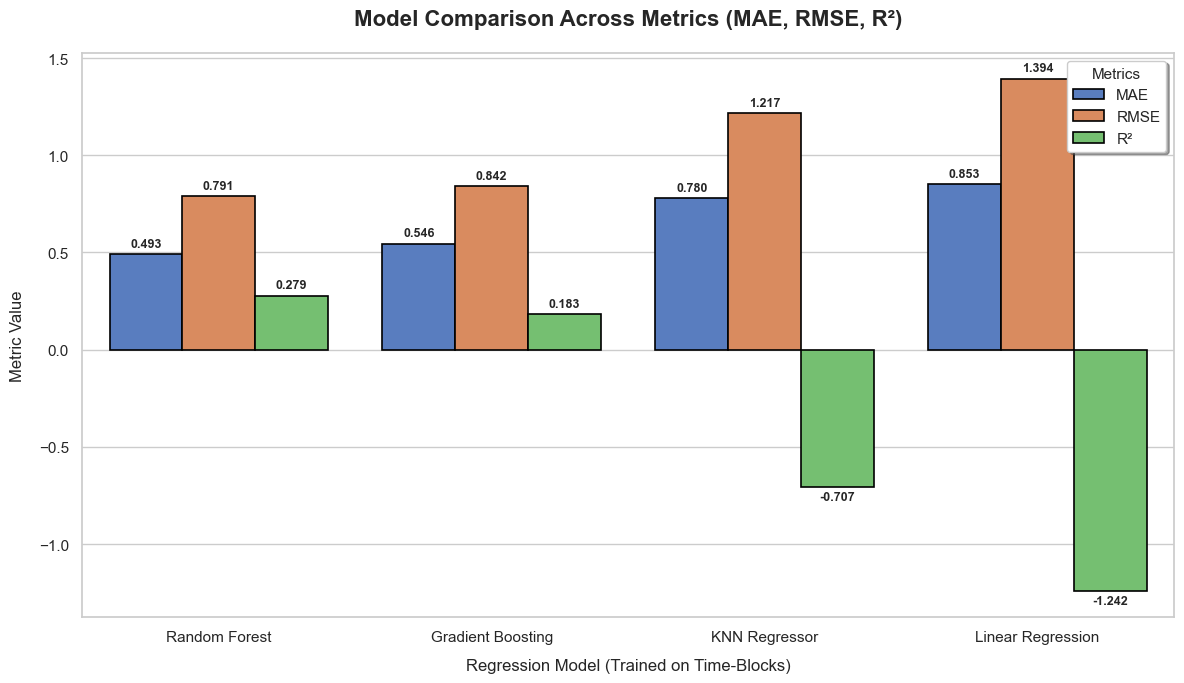

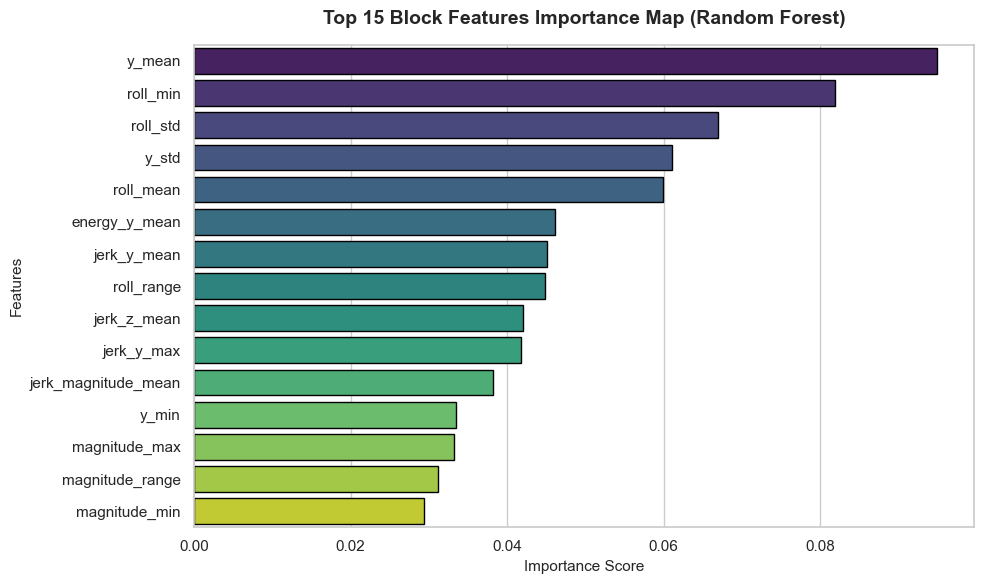

In [33]:
# Generate block-level features and target durations
X, y = create_regression_segments_and_features(activity_df, window_size=60)

print(f"Features DataFrame Shape: {X.shape}")
print(f"Targets Array Shape:      {y.shape}")

print(f"Detected sit-stand transitions (blocks): {len(X)}")

if len(X) < 20:
    print("WARNING: Very few sit-stand transition blocks were detected.")

# Define feature names from the newly generated block features
feature_columns = list(X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Define estimators
models = {
    "Linear Regression": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
best_model = None
best_name = None
best_mae = np.inf

# Safe fallback if your print_horizontal_line helper isn't defined
try:
    print_horizontal_line()
except NameError:
    print("-" * 50)

# Training and Evaluation
for name, model in models.items():
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

    if mae < best_mae:
        best_mae = mae
        best_model = pipeline
        best_name = name

# Sort results by performance
results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

print("\nModel Comparison Table:")
display(results_df)
print(f"\nBest Model: {best_name}")

# Reshape the data for a clean clustered Seaborn plot (Model vs Metric Value)
df_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Value")

# Set cohesive style & palette 
sns.set_theme(style="whitegrid", palette="muted")
fig, ax = plt.subplots(figsize=(12, 7))

# Create a grouped bar chart showing all models and metrics side-by-side
sns.barplot(
    data=df_melted,
    x="Model",
    y="Value",
    hue="Metric",
    ax=ax,
    edgecolor="black",
    linewidth=1.2
)

# Aesthetics and cleanup
ax.set_title("Model Comparison Across Metrics (MAE, RMSE, R²)", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Regression Model (Trained on Time-Blocks)", fontsize=12, labelpad=10)
ax.set_ylabel("Metric Value", fontsize=12, labelpad=10)
ax.tick_params(axis="both", labelsize=11)

# Annotate heights on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", padding=3, fontsize=9, fontweight="semibold")

# Position the legend cleanly out of the way of the data labels
ax.legend(title="Metrics", title_fontsize='11', loc="upper right", frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# Feature Importance
tree_models = (RandomForestRegressor, GradientBoostingRegressor)
trained_model = best_model.named_steps["model"]

if isinstance(trained_model, tree_models):
    # Plot top 15 features 
    importance = pd.Series(
        trained_model.feature_importances_,
        index=feature_columns
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    
    sns.barplot(
        x=importance.values, 
        y=importance.index, 
        hue=importance.index,
        legend=False,
        palette="viridis",
        edgecolor="black",
        linewidth=1
    )
    
    plt.title(f"Top 15 Block Features Importance Map ({best_name})", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Importance Score", fontsize=11)
    plt.ylabel("Features", fontsize=11)
    plt.tight_layout()
    plt.show()

Split data into train, test and Validation Sets (User-based splitting to avoid data leakage)

In [34]:
# Extract unique users and shuffle/slice them deterministically
unique_users = activity_df['user_id'].unique()

train_users = unique_users[:30]
val_users = unique_users[30:33]
test_users = unique_users[33:]

# Filter the DataFrames based on the user groups
train_df = activity_df[activity_df['user_id'].isin(train_users)]
val_df = activity_df[activity_df['user_id'].isin(val_users)]
test_df = activity_df[activity_df['user_id'].isin(test_users)]

# Generate 3D windows for all three subsets
X_train_3d, y_train_strings = create_segments_and_labels(train_df)
X_val_3d, y_val_strings = create_segments_and_labels(val_df)
X_test_3d, y_test_strings = create_segments_and_labels(test_df)

# Fit the LabelEncoder on the training set and transform all targets
le = LabelEncoder()
y_train = le.fit_transform(y_train_strings)
y_val = le.transform(y_val_strings)
y_test = le.transform(y_test_strings)

print_horizontal_line()
print(le.classes_)
print_horizontal_line()

# Print out shapes to verify the distribution
print(f"Train shapes:      X Train = {X_train_3d.shape}, y = {y_train.shape}")
print(f"Validation shapes: X Val = {X_val_3d.shape}, y = {y_val.shape}")
print(f"Test shapes:       X Test = {X_test_3d.shape}, y = {y_test.shape}")

label ---> 0
Processing user 1 with activity 0 and 2909 samples.
label ---> 1
Processing user 1 with activity 1 and 10871 samples.
label ---> 4
Processing user 1 with activity 4 and 3095 samples.
label ---> 5
Processing user 1 with activity 5 and 12758 samples.
label ---> 1
Processing user 2 with activity 1 and 11664 samples.
label ---> 5
Processing user 2 with activity 5 and 11648 samples.
label ---> 0
Processing user 3 with activity 0 and 3261 samples.
label ---> 1
Processing user 3 with activity 1 and 10857 samples.
label ---> 2
Processing user 3 with activity 2 and 1547 samples.
label ---> 3
Processing user 3 with activity 3 and 2721 samples.
label ---> 4
Processing user 3 with activity 4 and 3359 samples.
label ---> 5
Processing user 3 with activity 5 and 12801 samples.
label ---> 0
Processing user 4 with activity 0 and 1737 samples.
label ---> 1
Processing user 4 with activity 1 and 884 samples.
label ---> 2
Processing user 4 with activity 2 and 1204 samples.
label ---> 4
Process

Training LSTM and CNN

In [35]:
# 1. SIMULATED DATA RECONSTRUCTION (From EDA)
activity_df['x'] = pd.to_numeric(activity_df['x'], errors='coerce')
activity_df['y'] = pd.to_numeric(activity_df['y'], errors='coerce')
activity_df['z'] = pd.to_numeric(activity_df['z'], errors='coerce')
activity_df.dropna(inplace=True)

# Encode the categorical activity labels into integers
label_encoder = LabelEncoder()
activity_df['activity_encoded'] = label_encoder.fit_transform(activity_df['activity'])

# Accelerometer data requires framing into time windows (e.g., 4 seconds @ 20Hz = 80 samples)
TIME_STEPS = 100
STEP = 50  # 50% overlap for data augmentation

segments = []
labels = []

# Slide a window across the dataset to extract features
for i in range(0, len(activity_df) - TIME_STEPS, STEP):
    xs = activity_df['x'].values[i: i + TIME_STEPS]
    ys = activity_df['y'].values[i: i + TIME_STEPS]
    zs = activity_df['z'].values[i: i + TIME_STEPS]
    
    # Retrieve the most frequent label in this specific window
    label = stats.mode(activity_df['activity_encoded'].values[i: i + TIME_STEPS], keepdims=False)[0]
    
    segments.append([xs, ys, zs])
    labels.append(label)

# Convert to numpy arrays
# Shape of segments: (N_windows, 3_axes, 100_time_steps)
X_signals = np.asarray(segments, dtype=np.float32)
y = np.asarray(labels, dtype=np.int32)

# For statistical models like Random Forest, we flatten or extract summary statistics.
# Let's extract Mean, Standard Deviation, and Max/Min per axis for each window:
X_features = []
for window in X_signals:
    features = [
        np.mean(window[0]), np.std(window[0]), np.max(window[0]), np.min(window[0]), # X stats
        np.mean(window[1]), np.std(window[1]), np.max(window[1]), np.min(window[1]), # Y stats
        np.mean(window[2]), np.std(window[2]), np.max(window[2]), np.min(window[2])  # Z stats
    ]
    X_features.append(features)

X_features = np.array(X_features)


X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}\n")


print("Training Random Forest Classifier... Please wait...")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred = rf_model.predict(X_test)

# Output evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print("=" * 60)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("=" * 60)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in label_encoder.classes_]))

Training set shape: (16316, 12)
Testing set shape: (4079, 12)

Training Random Forest Classifier... Please wait...
Model Accuracy: 95.24%

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.84      0.86       390
           1       0.97      0.98      0.97      1190
           2       1.00      0.97      0.98       229
           3       0.99      0.97      0.98       189
           4       0.90      0.84      0.87       476
           5       0.96      0.99      0.97      1605

    accuracy                           0.95      4079
   macro avg       0.95      0.93      0.94      4079
weighted avg       0.95      0.95      0.95      4079



In [36]:
activity_df['x'] = pd.to_numeric(activity_df['x'], errors='coerce')
activity_df['y'] = pd.to_numeric(activity_df['y'], errors='coerce')
activity_df['z'] = pd.to_numeric(activity_df['z'], errors='coerce')
activity_df.dropna(inplace=True)

label_encoder = LabelEncoder()
activity_df['activity_encoded'] = label_encoder.fit_transform(activity_df['activity'])

segments = []
labels = []

# Sliding window
for i in range(0, len(activity_df) - TIME_STEPS, STEP):
    xs = activity_df['x'].values[i: i + TIME_STEPS]
    ys = activity_df['y'].values[i: i + TIME_STEPS]
    zs = activity_df['z'].values[i: i + TIME_STEPS]
    
    label = stats.mode(activity_df['activity_encoded'].values[i: i + TIME_STEPS], keepdims=False)[0]
    
    # Deep Learning models expect the shape: (time_steps, features/channels)
    # Stack the X, Y, Z data horizontally into shape (80, 3)
    segments.append(np.column_stack((xs, ys, zs)))
    labels.append(label)

X_signals = np.asarray(segments, dtype=np.float32)
y = np.asarray(labels, dtype=np.int32)

# One-hot encode labels for deep learning output layer
num_classes = len(np.unique(y))
y_categorical = to_categorical(y, num_classes=num_classes)

# Train-Test Split (Maintains temporal window alignment)
X_train, X_test, y_train, y_test = train_test_split(
    X_signals, y_categorical, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Shape for Deep Learning: {X_train.shape}") # Expecting (N_samples, 100, 3)
print(f"Number of target classes: {num_classes}\n")

#  CNN 
print("--- Training CNN Model ---")

cnn_model = Sequential([
    # Conv1D looks across the time steps. Input shape is (100 time_steps, 3 channels)
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(TIME_STEPS, 3)),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    Dropout(0.5),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the CNN
cnn_history = cnn_model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1
)

# Evaluate CNN
cnn_preds = np.argmax(cnn_model.predict(X_test), axis=1)
y_test_true = np.argmax(y_test, axis=1)
class_names = [str(c) for c in label_encoder.classes_]

print("\n" + "="*40 + "\nCNN RESULTS\n" + "="*40)
print(f"CNN Accuracy: {accuracy_score(y_test_true, cnn_preds) * 100:.2f}%")
print(classification_report(y_test_true, cnn_preds, target_names=class_names))


# 3. MODEL 2: LSTM 
print_horizontal_line()
print("\n--- Training LSTM Model ---")
print_horizontal_line()


lstm_model = Sequential([
    # LSTM handles temporal sequence dependencies perfectly
    LSTM(64, input_shape=(TIME_STEPS, 3), return_sequences=True),
    LSTM(64),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the LSTM
lstm_history = lstm_model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1
)

# Evaluate LSTM
lstm_preds = np.argmax(lstm_model.predict(X_test), axis=1)

print("\n" + "="*40 + "\nLSTM RESULTS\n" + "="*40)
print(f"LSTM Accuracy: {accuracy_score(y_test_true, lstm_preds) * 100:.2f}%")
print(classification_report(y_test_true, lstm_preds, target_names=class_names))

Data Shape for Deep Learning: (16316, 100, 3)
Number of target classes: 6

--- Training CNN Model ---


/Users/ikenjokudc/projects/human-activity-recorgnition/.conda/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7845 - loss: 0.5876 - val_accuracy: 0.8609 - val_loss: 0.3949
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8842 - loss: 0.3265 - val_accuracy: 0.8848 - val_loss: 0.2979
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9166 - loss: 0.2366 - val_accuracy: 0.9185 - val_loss: 0.2557
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9327 - loss: 0.1895 - val_accuracy: 0.9363 - val_loss: 0.2083
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9457 - loss: 0.1561 - val_accuracy: 0.9326 - val_loss: 0.2090
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9534 - loss: 0.1284 - val_accuracy: 0.9387 - val_loss: 0.2149
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9634 - loss: 0.1010 - val_accuracy: 0.9424 - val_loss: 0.1906
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9709 - loss: 0.0871 - val_accuracy: 

/Users/ikenjokudc/projects/human-activity-recorgnition/.conda/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


230/230 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.6381 - loss: 1.0756 - val_accuracy: 0.6857 - val_loss: 0.8832
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - accuracy: 0.7252 - loss: 0.8218 - val_accuracy: 0.7463 - val_loss: 0.7211
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.7503 - loss: 0.7289 - val_accuracy: 0.7684 - val_loss: 0.6217
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.7826 - loss: 0.6026 - val_accuracy: 0.7904 - val_loss: 0.5729
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - accuracy: 0.8070 - loss: 0.5404 - val_accuracy: 0.8168 - val_loss: 0.4628
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.8240 - loss: 0.4722 - val_accuracy: 0.8248 - val_loss: 0.4246
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.8225 - loss: 0.4747 - val_accuracy: 0.8309 - val_loss: 0.4277
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - accuracy: 0.8361 - loss: 0.4309 - val_accurac

##### Visualise Model Performance across the different classes
---

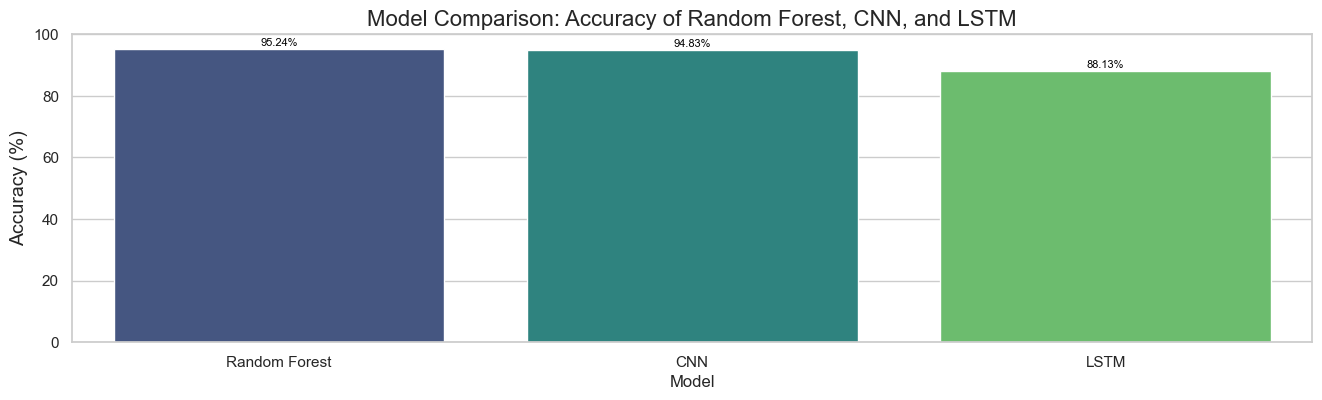

In [37]:
# create a dataframe of the results from the CNN, LSTM, and Random Forest models for comparison
results_df = pd.DataFrame({
    'Model': ['Random Forest', 'CNN', 'LSTM'],
    'Accuracy': [
        # FIXED: Changed y_test to y_test_true to match y_pred's format
        accuracy_score(y_test_true, y_pred) * 100,
        accuracy_score(y_test_true, cnn_preds) * 100,
        accuracy_score(y_test_true, lstm_preds) * 100
    ]
})

# plot the results in a bar chart
plt.figure(figsize=(16, 4))
# Note: Added hue='Model' and legend=False to comply with modern Seaborn styling requirements
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('Model Comparison: Accuracy of Random Forest, CNN, and LSTM', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.ylim(0, 100)

# annotate the bars with the accuracy values
for index, row in results_df.iterrows():
    plt.text(index, row.Accuracy + 1, f"{row.Accuracy:.2f}%", color='black', ha="center", fontsize=8)

plt.show()

In [38]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ELU, MaxPool1D, 
    Bidirectional, GRU, Add, GlobalAveragePooling1D, 
    Dense, Reshape, Multiply
)
from tensorflow.keras.models import Model

def squeeze_and_excitation_block(input_tensor, ratio=16):
    """
    Squeeze-and-Excitation Block for channel-wise feature attention recalibration.
    """
    filters = input_tensor.shape[-1]
    
    # Squeeze phase: Global Average Pooling across the temporal axis
    se = GlobalAveragePooling1D()(input_tensor)
    se = Reshape((1, filters))(se)
    
    # Excitation phase: Two-stage bottleneck dense scaling
    se = Dense(filters // ratio, activation='relu', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', use_bias=False)(se)
    
    # Scale phase: Weight channels back into the input sequence
    return Multiply()([input_tensor, se])

def convolutional_block_convb(input_tensor, filters, kernel_size=3, pool_size=2):
    """
    ConvB Layer: Extracts spatial/low-level features from sensor sequences.
    Consists of Conv1D -> Batch Normalization -> ELU -> Max Pooling.
    """
    x = Conv1D(filters, kernel_size=kernel_size, padding='same')(input_tensor)
    x = BatchNormalization()(x)
    x = ELU()(x)
    x = MaxPool1D(pool_size=pool_size, padding='same')(x)
    return x

def build_convres_bigru_se(input_shape, num_classes):
    """
    Constructs the complete hybrid ConvResBiGRU-SE network structure.
    """
    inputs = Input(shape=input_shape)
    
    # --- 1. Base Convolutional Feature Extraction (ConvB) ---
    conv_out = convolutional_block_convb(inputs, filters=64, kernel_size=5, pool_size=2)
    
    # --- 2. Temporal Analysis Layer (Bidirectional GRU) ---
    # return_sequences=True keeps the output 3D so it can feed the next structural blocks
    gru_out = Bidirectional(GRU(64, return_sequences=True))(conv_out)
    
    # --- 3. Residual Mapping Integration ---
    # Match spatial and feature dimensions between Conv output and BiGRU output
    shortcut = Conv1D(128, kernel_size=1, padding='same')(conv_out) 
    shortcut = BatchNormalization()(shortcut)
    
    # Residual Skip-Connection Addition
    res_addition = Add()([gru_out, shortcut])
    res_out = ELU()(res_addition)
    
    # --- 4. Squeeze-and-Excitation Recalibration ---
    se_out = squeeze_and_excitation_block(res_out, ratio=16)
    
    # --- 5. Classification Output Head ---
    pooling_layer = GlobalAveragePooling1D()(se_out)
    outputs = Dense(num_classes, activation='softmax')(pooling_layer)
    
    model = Model(inputs, outputs, name="ConvResBiGRU_SE")
    return model

# --- Notebook Integration Config ---
# For WISDM data sampled at 20Hz using a sliding window of 100 timestamps (6.4 seconds)
TIME_STEPS = 100
CHANNELS = 3      # Tri-axial raw sensor data: x, y, z metrics
NUM_CLASSES = 6   # Standard target actions (Walking, Jogging, etc.)

# Instantiate and compile the architecture
model = build_convres_bigru_se(input_shape=(TIME_STEPS, CHANNELS), num_classes=NUM_CLASSES)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# Train the ConvResBiGRU-SE model
# 1. Compute evaluation metrics from predictions
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

# Train the model to optimize its weights before evaluating it
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# 2. Package metrics into a row DataFrame
new_row = pd.DataFrame([{
    'Model': 'ConvResBiGRU-SE',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}])

# 3. Concatenate safely into results_df
try:
    results_df = pd.concat([results_df, new_row], ignore_index=True)
    results_df.drop_duplicates(subset=['Model'], keep='last', inplace=True)
except NameError:
    results_df = new_row

# Display updated table
display(results_df)

Model: "ConvResBiGRU_SE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 100, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 100, 64)   │      1,024 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 100, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ elu (ELU)           │ (None, 100, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 50, 64)    │          0 │ elu[0][0]         │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 50, 128)   │      8,320 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 50, 128)   │     49,920 │ max_pooling1d_1[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 128)   │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 128)   │          0 │ bidirectional[0]… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ elu_1 (ELU)         │ (None, 50, 128)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ elu_1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 128)    │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1, 8)      │      1,024 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 128)    │      1,024 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 50, 128)   │          0 │ elu_1[0][0],      │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 6)         │        774 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 62,854 (245.52 KB)

 Trainable params: 62,470 (244.02 KB)

 Non-trainable params: 384 (1.50 KB)

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.7826 - loss: 0.6262 - val_accuracy: 0.6863 - val_loss: 0.8200
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.8793 - loss: 0.3381 - val_accuracy: 0.8906 - val_loss: 0.3002
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9165 - loss: 0.2390 - val_accuracy: 0.9145 - val_loss: 0.2413
Epoch 4/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9377 - loss: 0.1836 - val_accuracy: 0.9470 - val_loss: 0.1475
Epoch 5/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9517 - loss: 0.1449 - val_accuracy: 0.9599 - val_loss: 0.1164
Epoch 6/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9596 - loss: 0.1218 - val_accuracy: 0.9651 - val_loss: 0.1023
Epoch 7/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9667 - loss: 0.1013 - val_accuracy: 0.9660 - val_loss: 0.0999
Epoch 8/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,95.243932,NaN,NaN,NaN
1,CNN,94.827164,NaN,NaN,NaN
2,LSTM,88.134347,NaN,NaN,NaN
3,ConvResBiGRU-SE,0.125276,0.200181,0.119798,0.12337


#### Timed-Up-and-Go (TUG)
---
The timed Up and Go (TUG) is a clinical test that evaluates functional mobility and fall risk. It measures the time it takes for a person to stand from a chair, walk threee meters(about 10 feet), turn around, walk back, and sit down again. 

The patient sits comfortably against a chair and rises on the word "Go", walks to a designated three-meter mark at a safe pace, turns around, and returns to seated. 

Equipment used include a standard arm chari, a stopwatch, a floor marker exactly three meters away and any assistive devices (eg walking aids)

Interpreting Results

The total time correlates with mobility and balance:Under 10 seconds: Normal mobility.11–20 seconds: Mostly independent with good functional mobility.Over 12–15 seconds: Often indicates an increased risk of falls and reduced functional independence.Over 30 seconds: Indicates significant mobility issues and a high risk of falling.


so far, we have identified when a person is: 
1. walking
2. sitting
3. standing
4. jogging
5. upstairs
6. downstairs
we have also identified:
1. distance covered during activity

---
### Actual Data Pre-processing Pipeline
---

In [ ]:
# ============================================================================
# Core Data Science & File Utilities -----------------------------------------
# ============================================================================
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks

# ============================================================================
# Data Visualization ---------------------------------------------------------
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# Scikit-Learn ---------------------------------------------------------------
# ============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# ============================================================================
# TensorFlow / Keras ---------------------------------------------------------
# ============================================================================
import tensorflow as tf

from tensorflow.keras.layers import (
    Conv1D,
    Dense,
    Dropout,
    Flatten,
    LSTM,
    MaxPooling1D,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

random_seed = 42

sns.set_theme(style="whitegrid")

current_dir = Path.cwd()
DATA_DIR = current_dir / 'data'
ORIGINAL_WISDM = DATA_DIR / 'WISDM_ar_v1.1_raw.csv'

def print_horizontal_line():
    print('-- -- -- -- ' * 50 )
    return

def run_pipeline(activity_df):
    return


# step one: load all the CSV files into separate dataframes

knee_df = pd.read_csv("data/2026-08-04_13-14-20/session-knee.csv")
lumbar_df = pd.read_csv("data/2026-08-04_13-14-20/session-lumbar.csv")
thigh_df = pd.read_csv("data/2026-08-04_13-14-20/session-knee.csv")

# step two: drop the "arduino_ms" column from each dataframe
lumbar_df.drop(columns=["arduino_ms"], inplace=True)
thigh_df.drop(columns=["arduino_ms"], inplace=True)
knee_df.drop(columns=["arduino_ms"], inplace=True)


# step three: take the column name "node_position" and add the value of the column each column name apart from pc_timestamp, arduino_ms, and node_position. For example, if the node_position is "lumbar", then the column "x" should be renamed to "lumbar_x", "y" to "lumbar_y", and so on.
lumbar_df.rename(columns=lambda x: f"lumbar_{x}" if x not in ["pc_timestamp", "arduino_ms", "node_position"] else x, inplace=True)
thigh_df.rename(columns=lambda x: f"thigh_{x}" if x not in ["pc_timestamp", "arduino_ms", "node_position"] else x, inplace=True)
knee_df.rename(columns=lambda x: f"knee_{x}" if x not in ["pc_timestamp", "arduino_ms", "node_position"] else x, inplace=True)

# step four: drop the node_position column from each dataframe
lumbar_df.drop(columns=["node_position"], inplace=True)
thigh_df.drop(columns=["node_position"], inplace=True)
knee_df.drop(columns=["node_position"], inplace=True)


# step five: make sure that the datasets are all of the same length.
len(lumbar_df), len(knee_df), len(thigh_df)

base_length = min(len(lumbar_df), len(knee_df), len(thigh_df))

lumbar_df = lumbar_df.iloc[:base_length]
knee_df = knee_df.iloc[:base_length]    
thigh_df = thigh_df.iloc[:base_length]

len(lumbar_df), len(knee_df), len(thigh_df)

# step six: since the dataframes are the same length, join them together. let pc_timestamp = (lumbar_df['pc_timestamp'] + thigh_df['pc_timestamp'] + knee_df['pc_timestamp']) / 3
pc_timestamp_avg = (lumbar_df['pc_timestamp'] + thigh_df['pc_timestamp'] + knee_df['pc_timestamp']) / 3
lumbar_df['pc_timestamp'] = pc_timestamp_avg

# step seven: remove the pc_timestamp column from the thigh_df and knee_df dataframes
thigh_df.drop(columns=["pc_timestamp"], inplace=True)
knee_df.drop(columns=["pc_timestamp"], inplace=True)

# step eight: concatenate the three dataframes together along the columns axis
merged_df = pd.concat([lumbar_df, thigh_df, knee_df], axis=1)
merged_df.columns
len(merged_df)



258